In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [3]:
def excel_to_csvs(filepath, output_dir=None):
    # Create output directory if not provided
    if output_dir is None:
        output_dir = os.path.splitext(filepath)[0] + "_csvs"
    os.makedirs(output_dir, exist_ok=True)

    # Load Excel file
    excel_file = pd.ExcelFile(filepath)
    
    # Iterate through each sheet and save as CSV
    for sheet_name in excel_file.sheet_names:
        df = pd.read_excel(filepath, sheet_name=sheet_name)
        csv_filename = f"{sheet_name}.csv"
        csv_path = os.path.join(output_dir, csv_filename)
        df.to_csv(csv_path, index=False)
        print(f"Saved: {csv_path}")

# Example usage
excel_to_csvs("/Users/jayashri/Desktop/ManualGranuleAnalysis.xlsx")

Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25529004Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603002Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603010Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603006Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609007Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609011Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609016Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609003Events550s.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25610006Events1050s.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25522003Events1050s.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25612002Events800s.csv


In [8]:
def plot_all_metrics_per_sweep(csv_path, trace_column='trace'):
    # Load data
    df = pd.read_csv(csv_path)
    
    # Ensure 'trace' column exists
    if trace_column not in df.columns:
        raise ValueError(f"'{trace_column}' column not found in the CSV.")

    # Convert all columns to numeric where possible, coerce errors
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    numeric_df[trace_column] = df[trace_column]  # Restore 'trace' if converted to NaN

    # Identify columns to plot (numeric, excluding the trace column)
    columns_to_plot = [col for col in numeric_df.columns if col != trace_column and numeric_df[col].dtype != 'O']

    # Group by sweep
    grouped = numeric_df.groupby(trace_column)

    for col in columns_to_plot:
        means = grouped[col].mean()
        sems = grouped[col].sem()

        plt.figure(figsize=(10, 6))
        plt.errorbar(means.index, means.values, yerr=sems.values, fmt='o', capsize=5)
        plt.title(f'{col} per Sweep (Mean ± SEM)')
        plt.xlabel('Sweep (Trace)')
        plt.ylabel(col)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

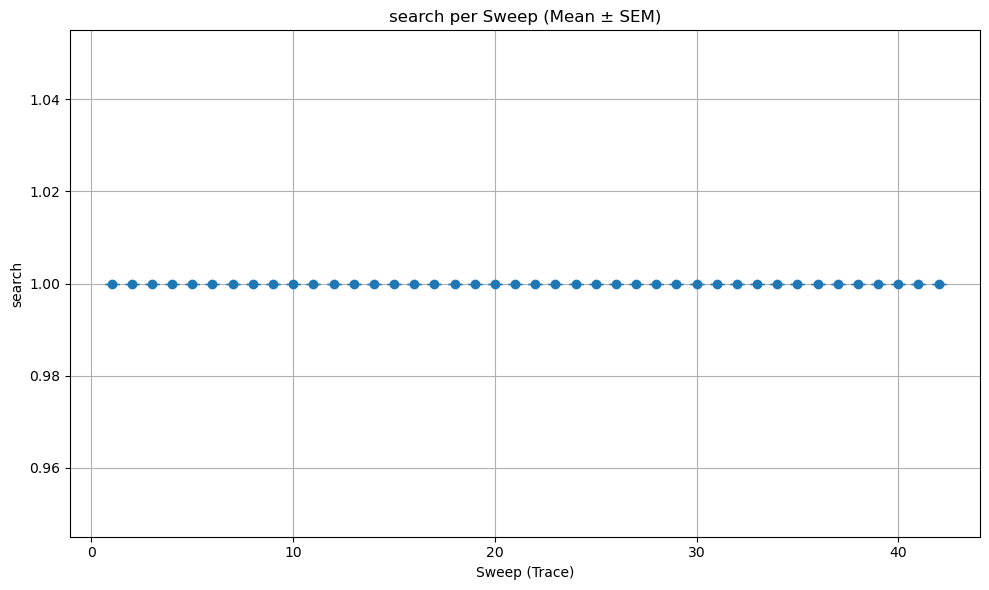

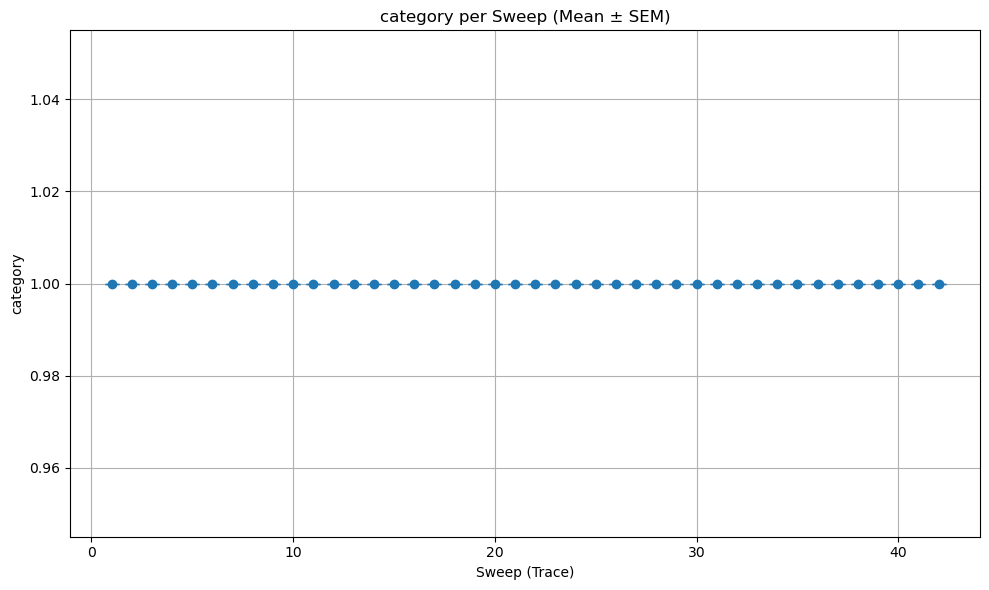

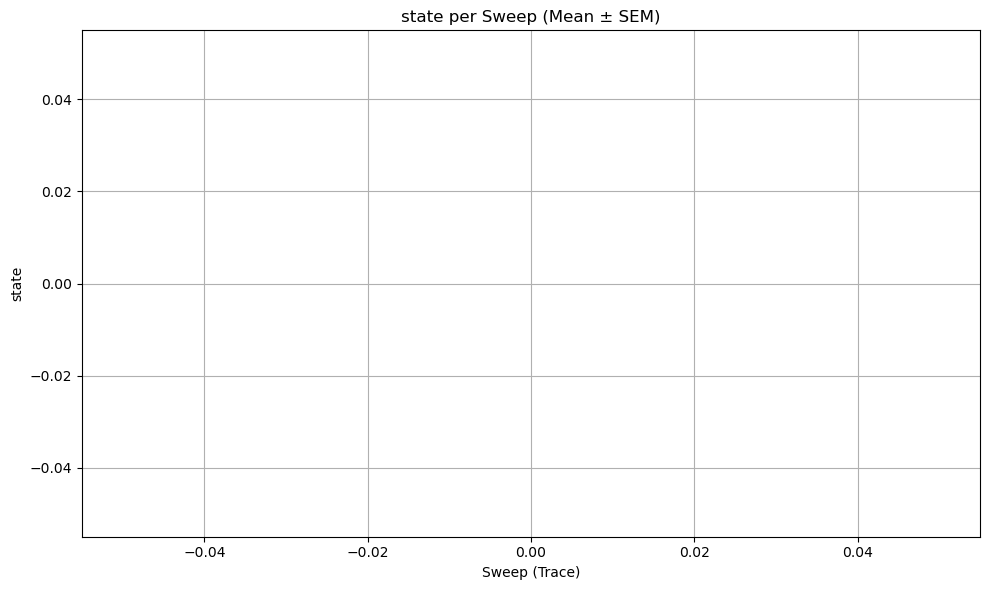

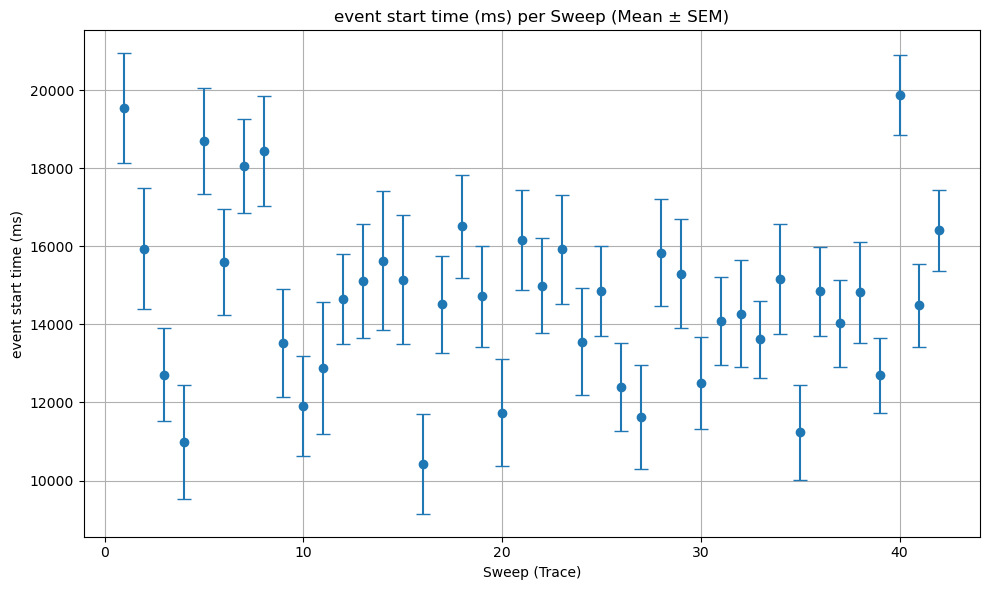

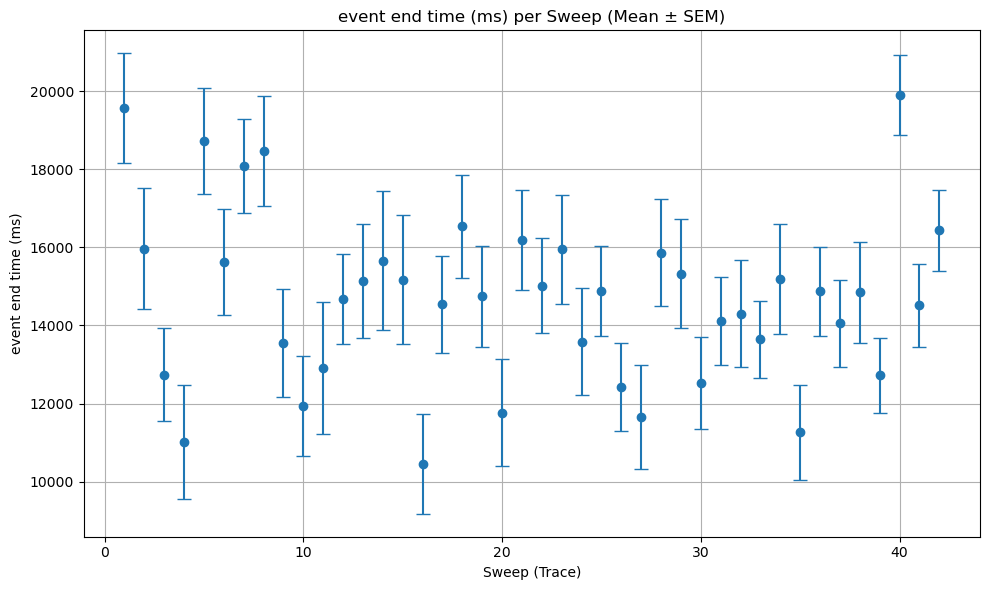

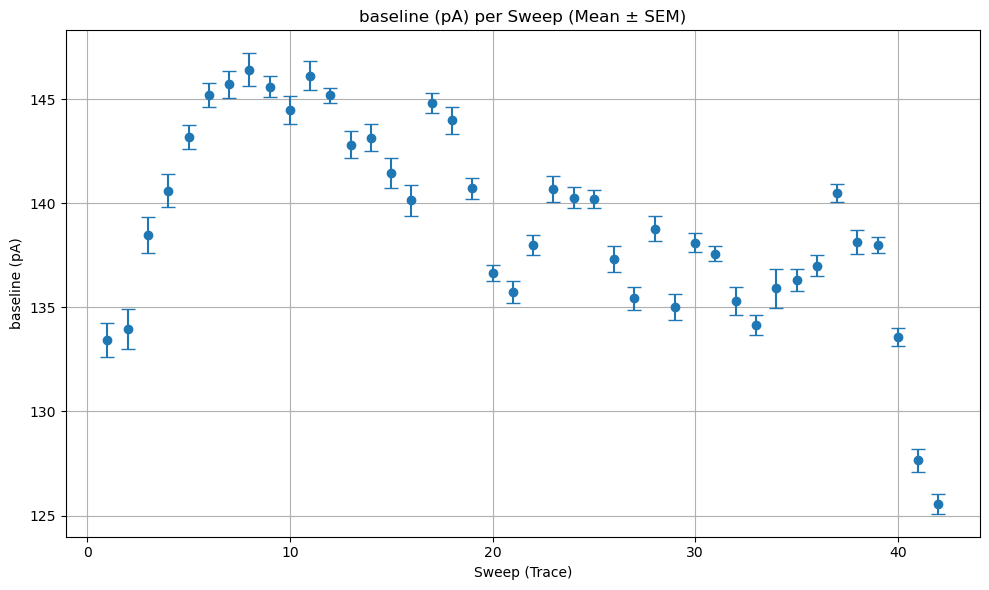

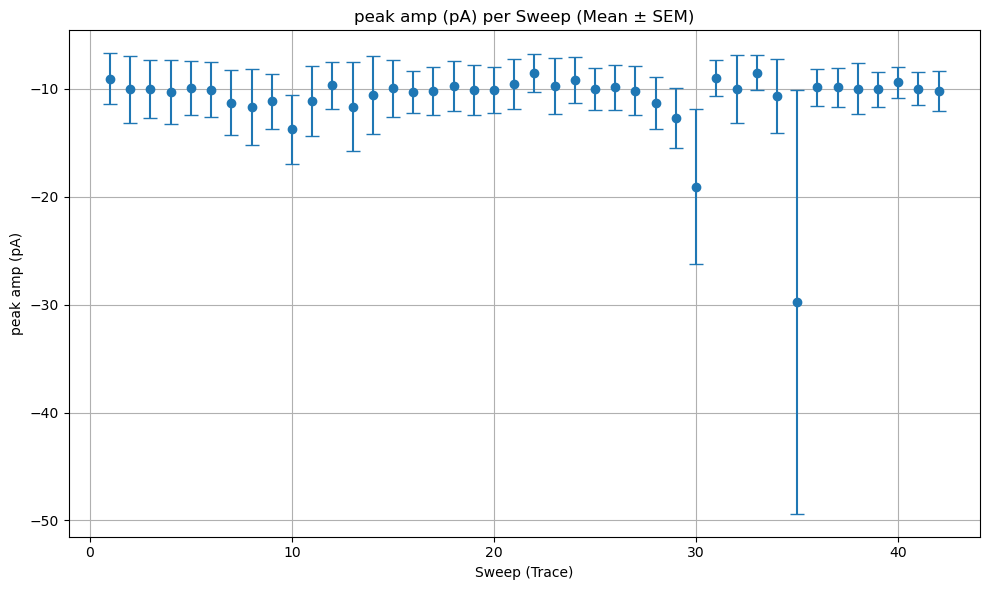

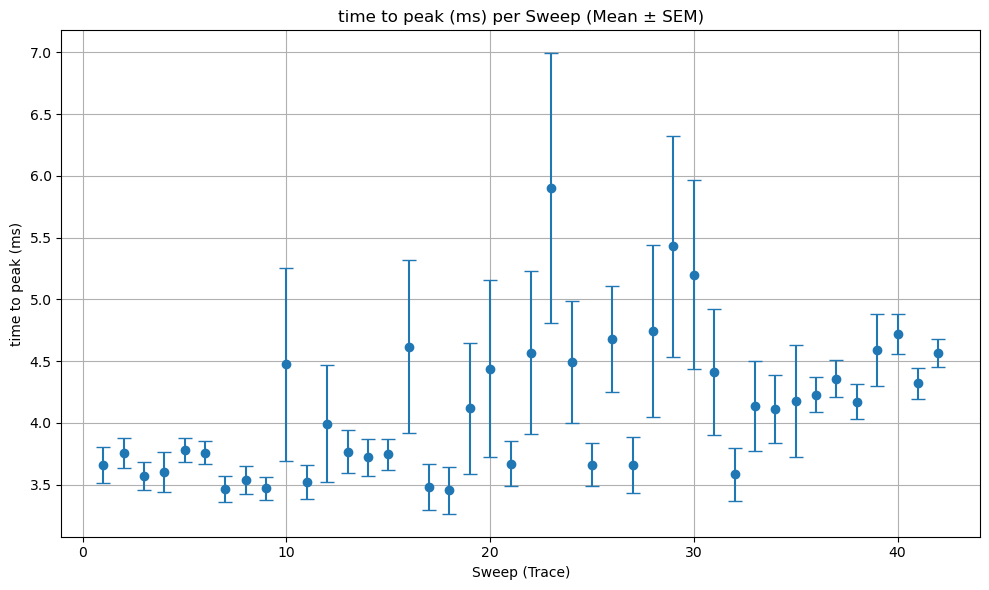

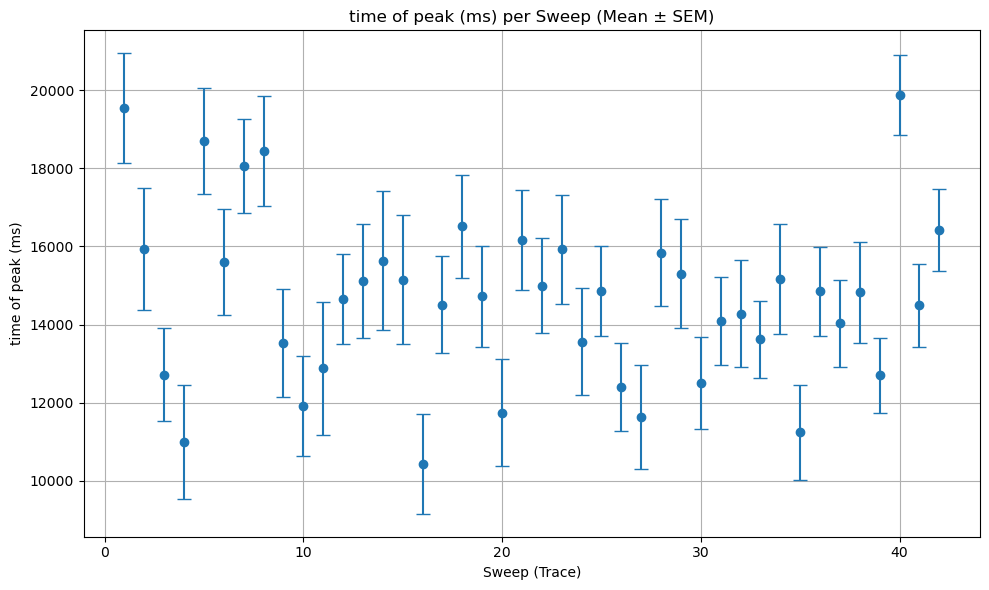

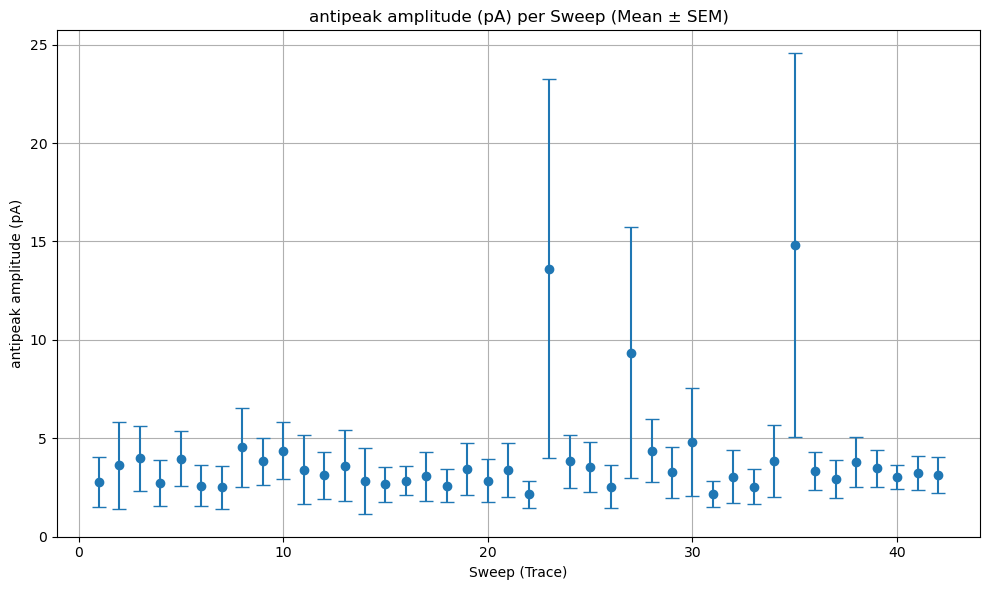

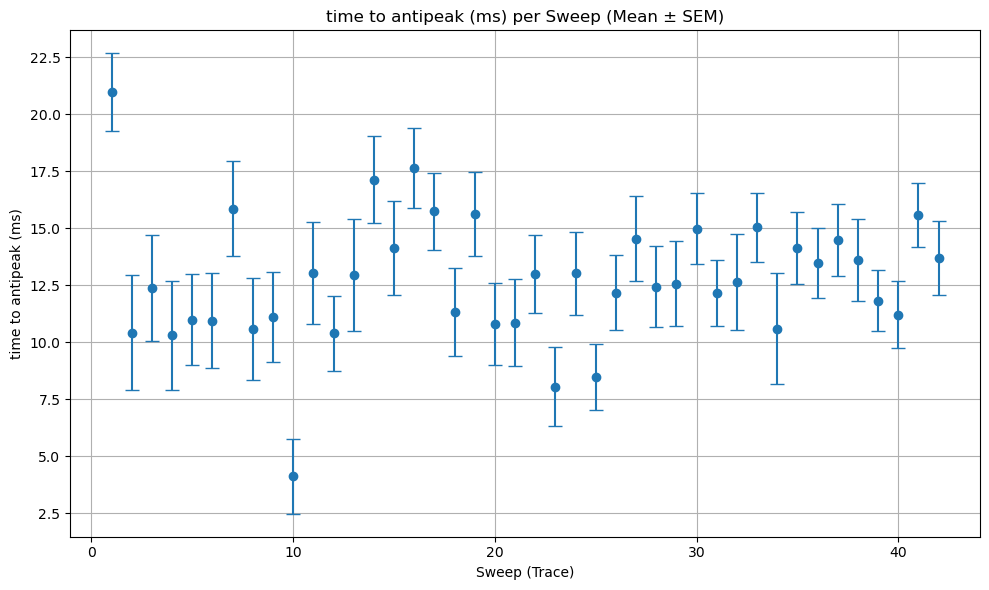

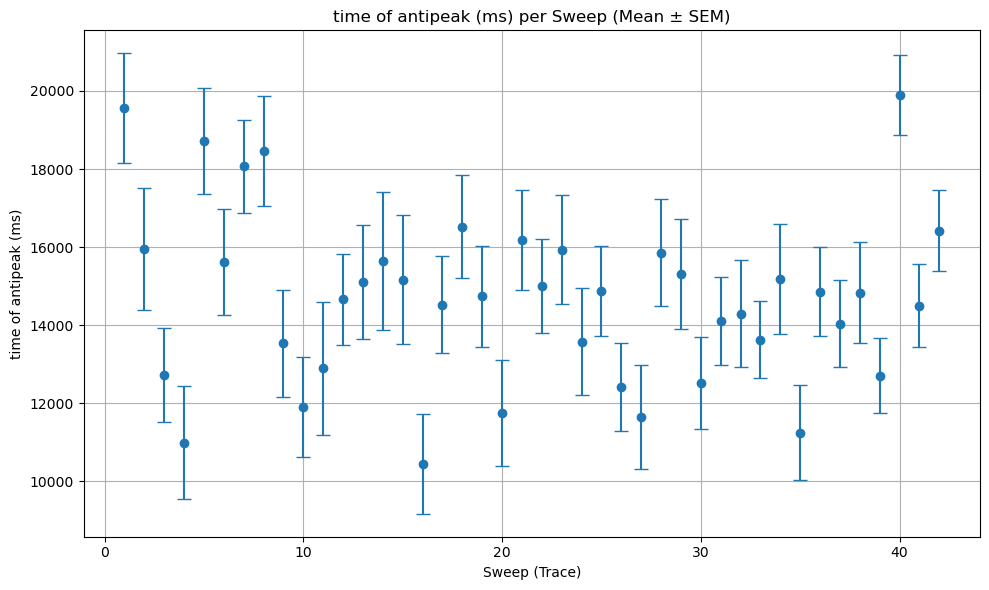

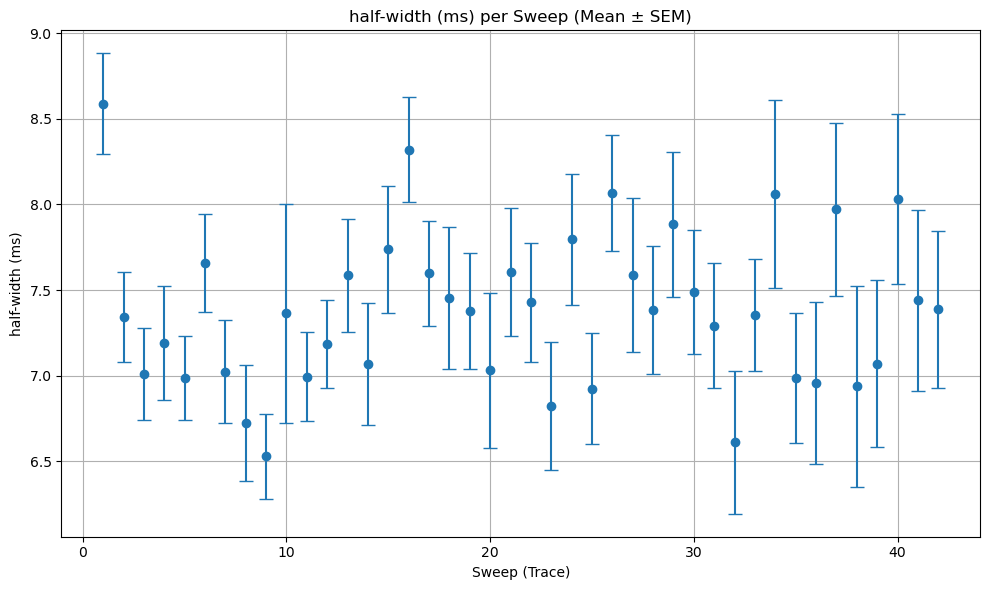

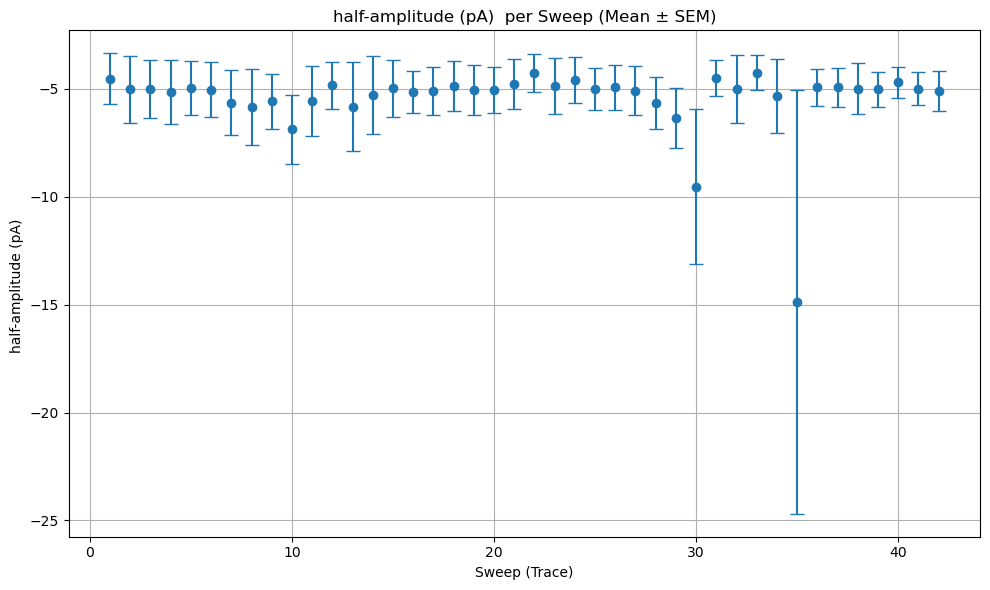

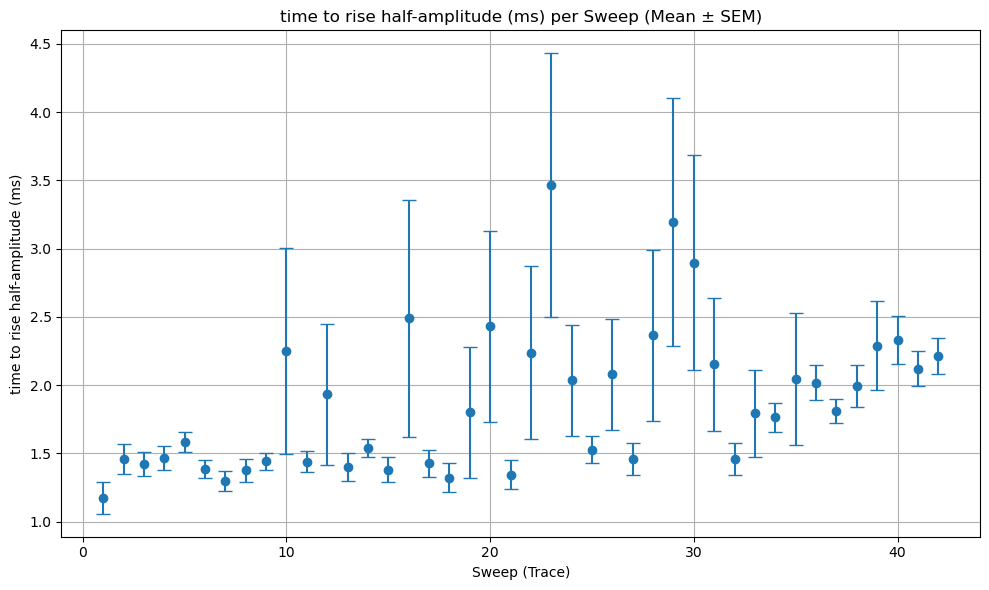

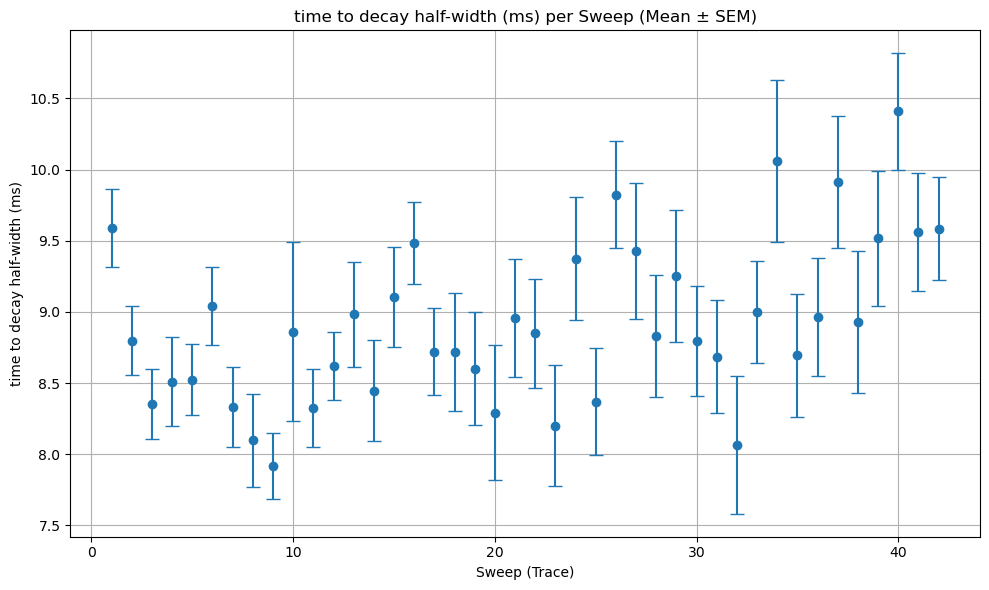

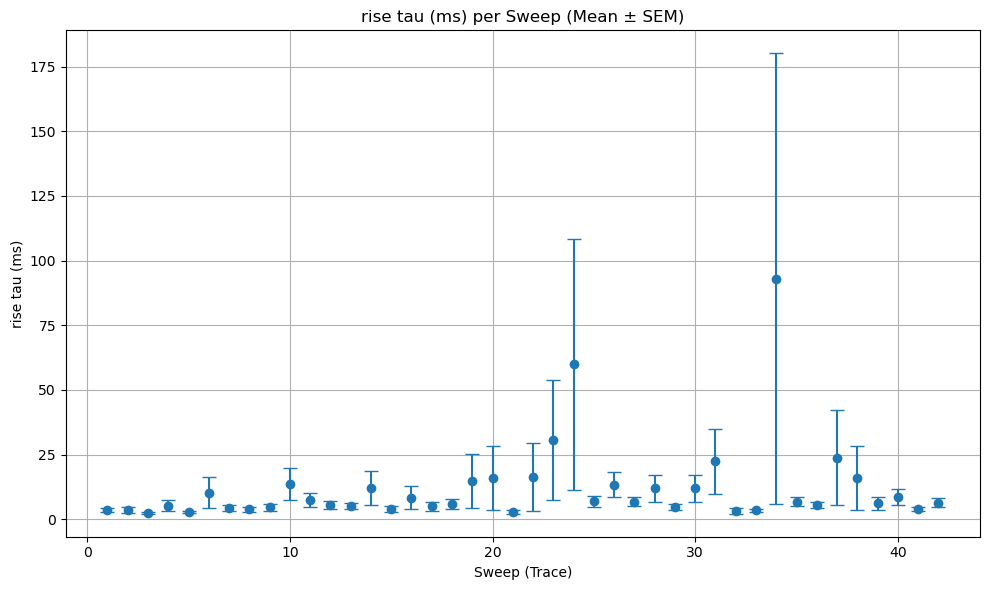

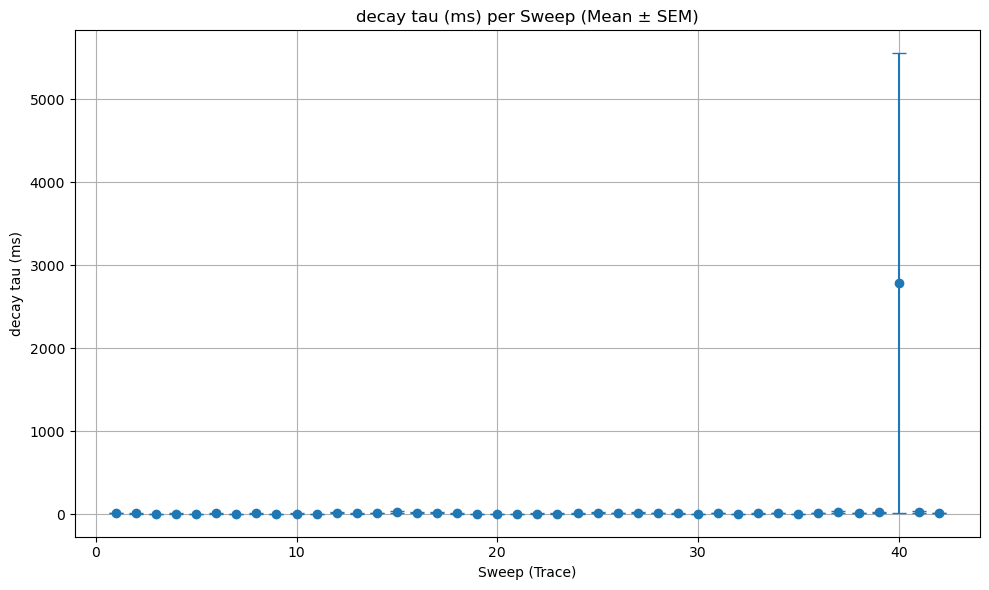

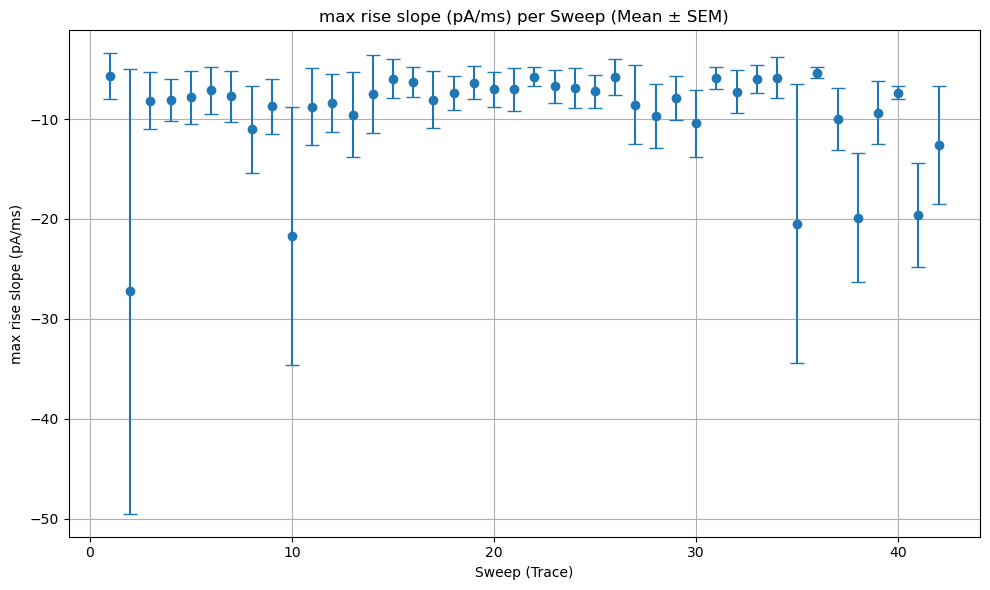

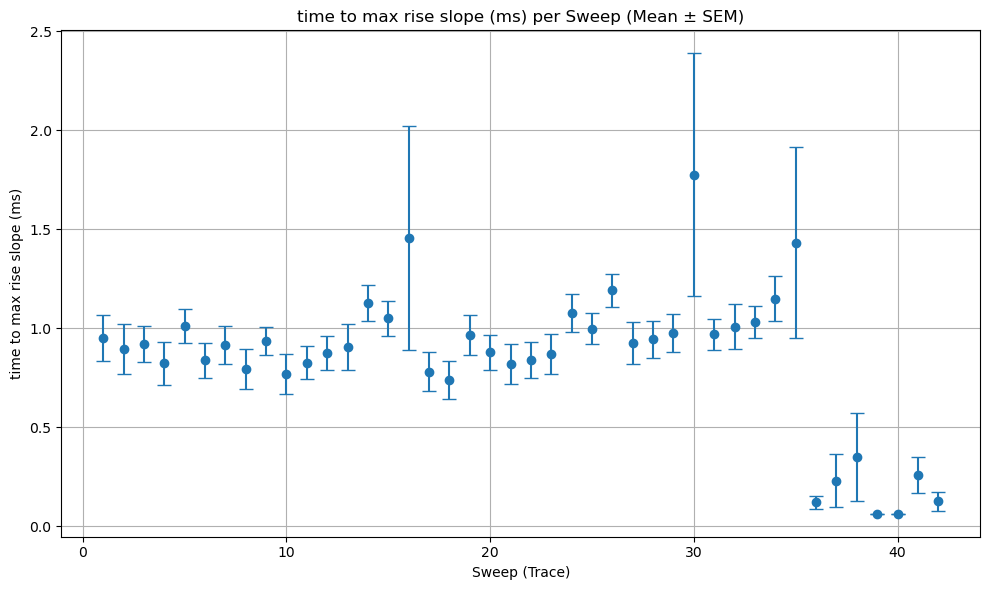

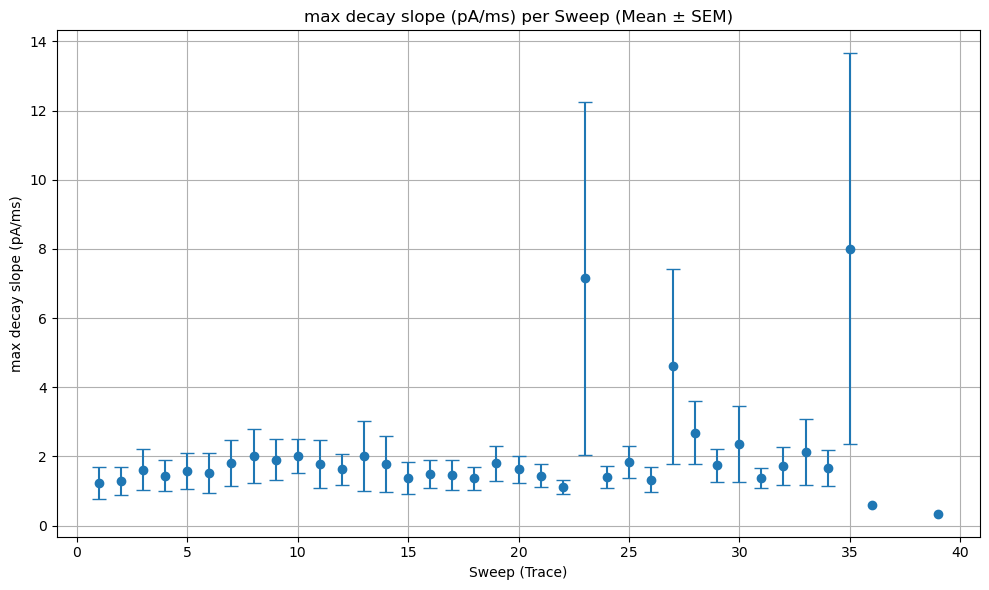

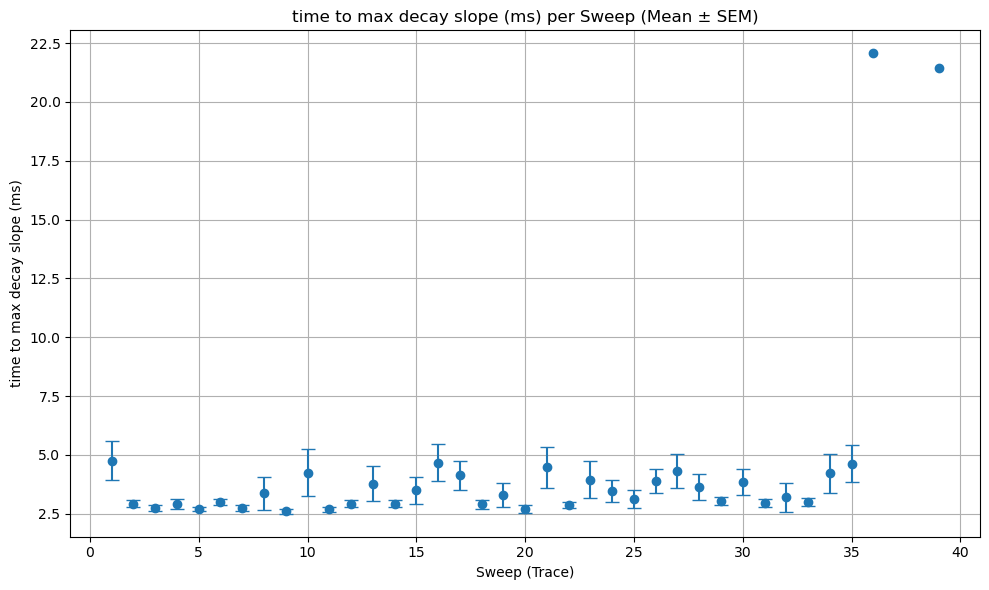

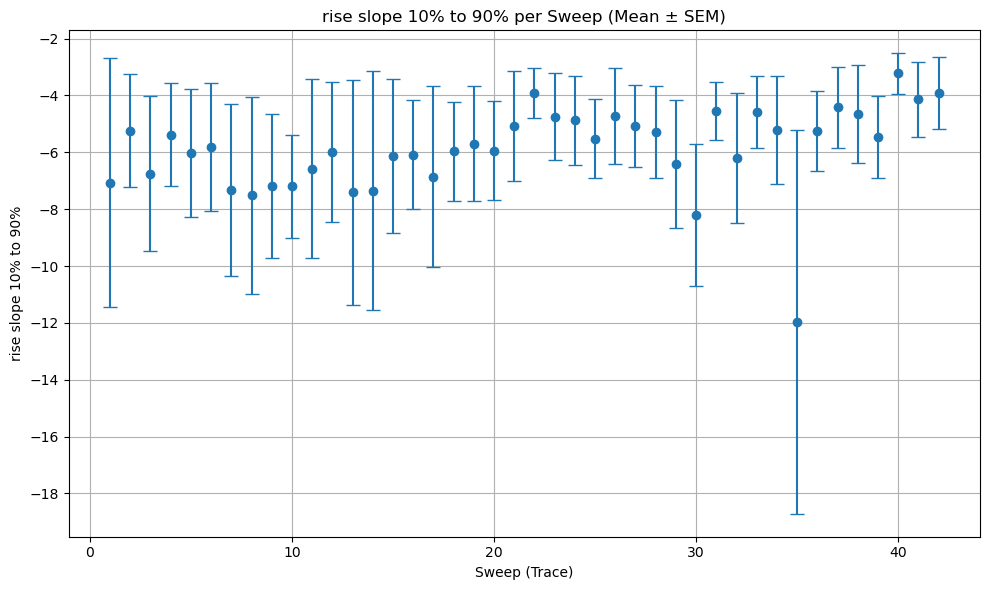

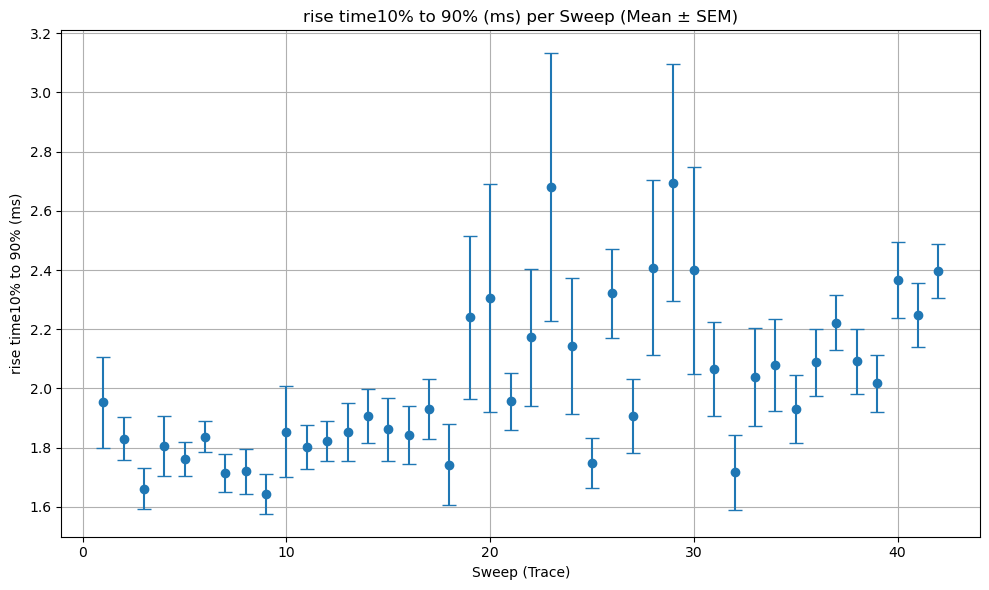

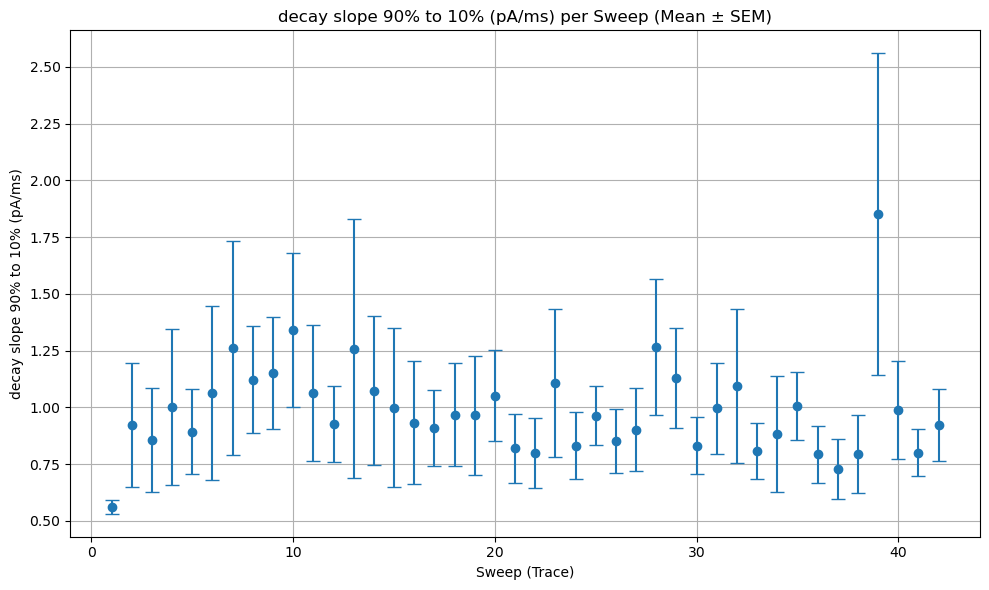

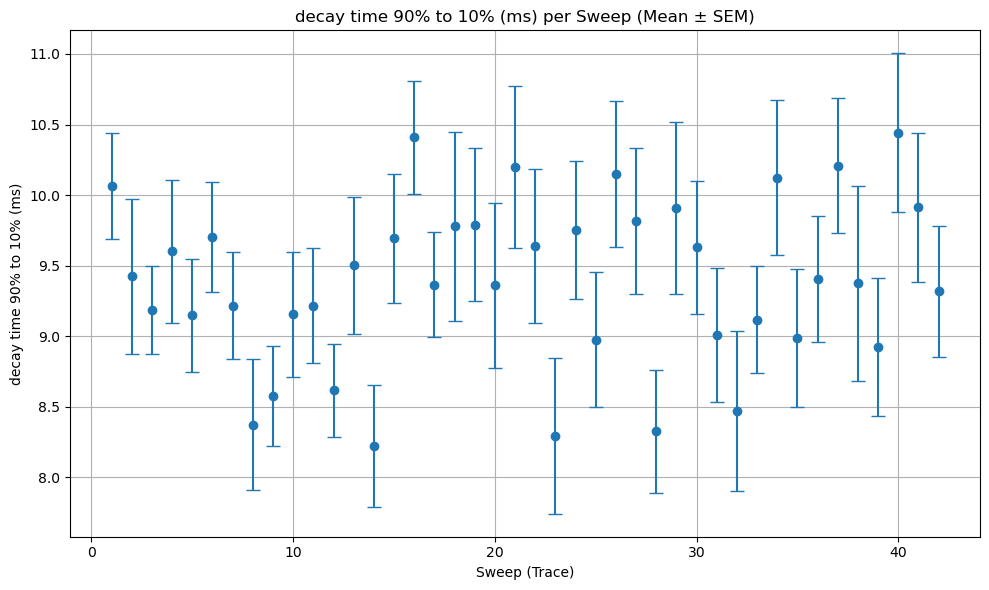

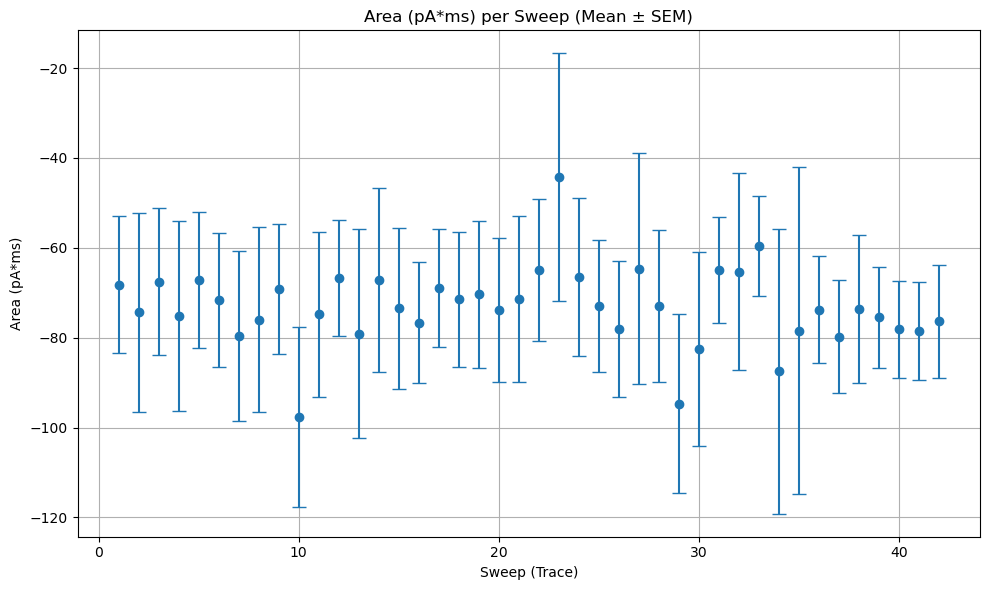

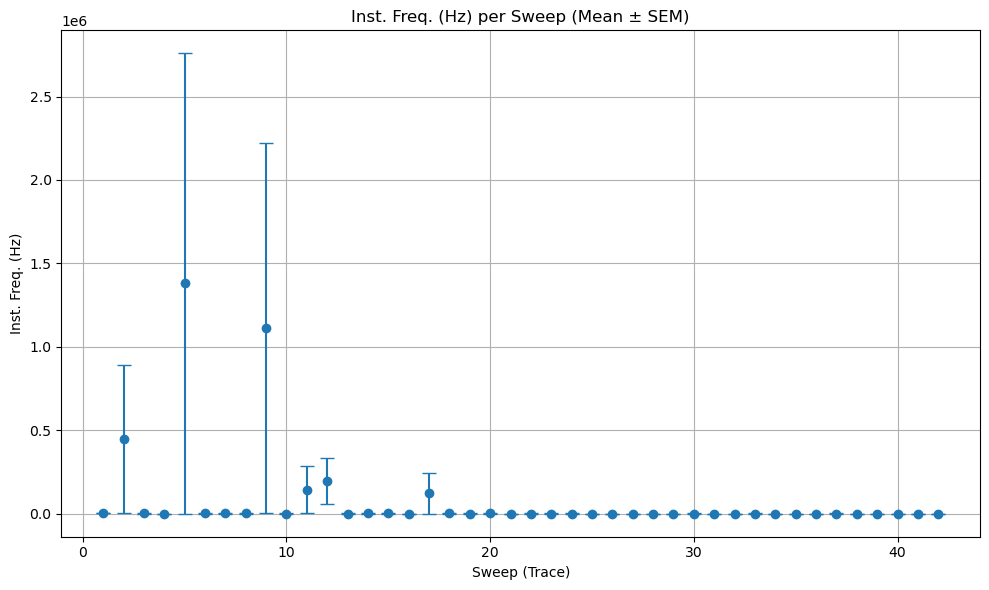

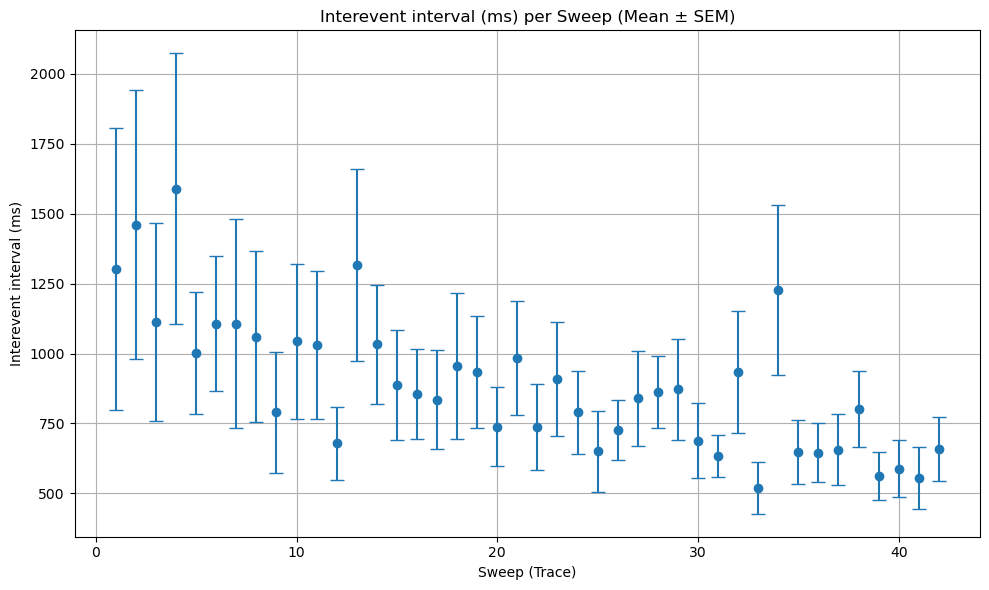

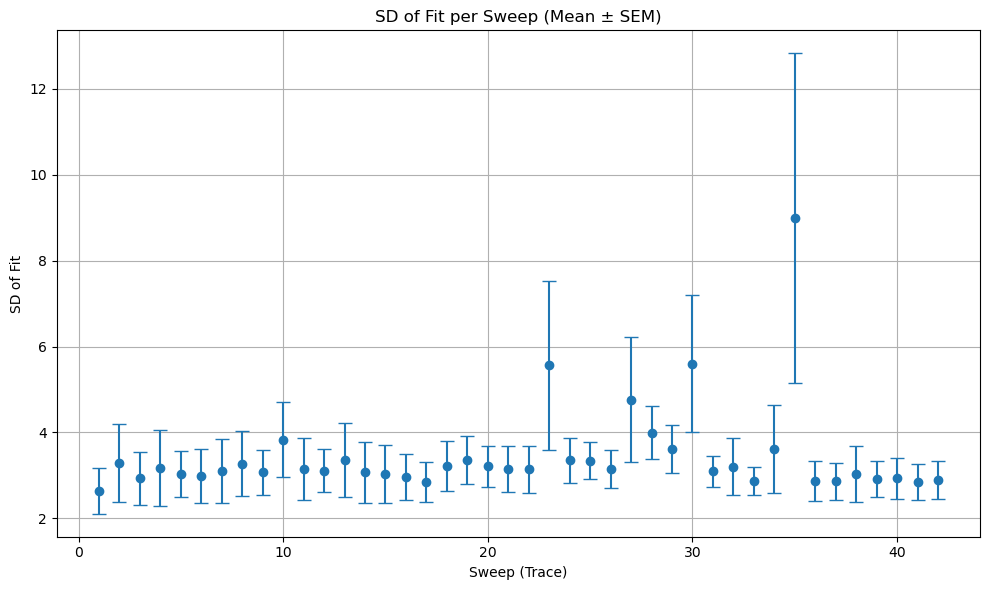

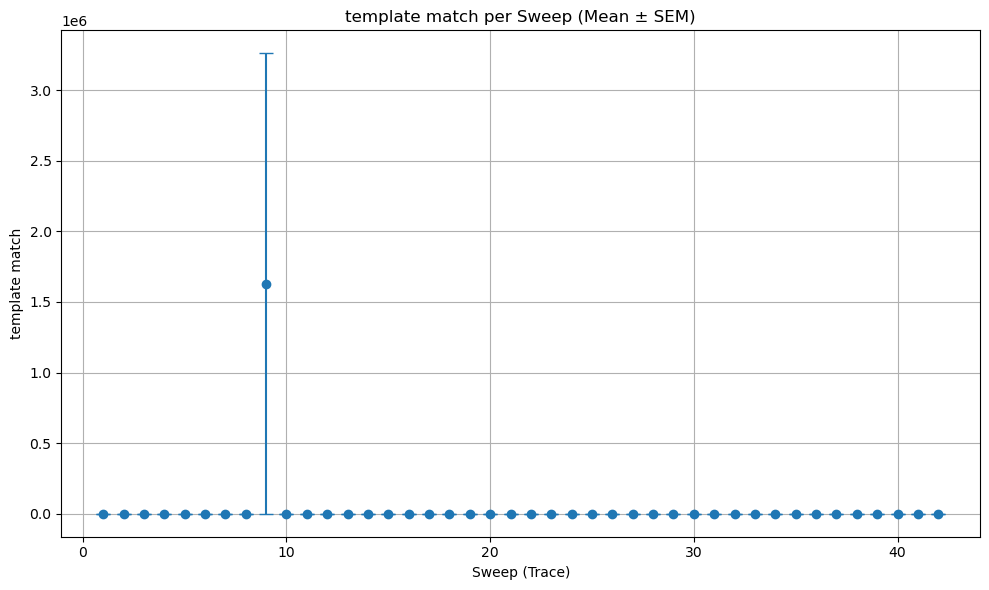

In [9]:
plot_all_metrics_per_sweep("/Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25612002.csv")

In [10]:
def plot_drug_application_effects(csv_path, start_sweep, end_sweep, trace_column='trace'):
    # Load and clean
    df = pd.read_csv(csv_path)
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    numeric_df[trace_column] = df[trace_column]  # Restore trace if it got coerced

    # Columns to analyze
    columns_to_plot = [col for col in numeric_df.columns if col != trace_column and numeric_df[col].dtype != 'O']

    # Define periods
    periods = {
        'Before': numeric_df[numeric_df[trace_column] < start_sweep],
        'During': numeric_df[(numeric_df[trace_column] > start_sweep) & (numeric_df[trace_column] < end_sweep)],
        'After': numeric_df[numeric_df[trace_column] > end_sweep]
    }

    # Plot each metric across periods
    for col in columns_to_plot:
        means = []
        sems = []
        labels = []

        for period_name, period_df in periods.items():
            col_values = period_df[col].dropna()
            if not col_values.empty:
                means.append(col_values.mean())
                sems.append(col_values.sem())
                labels.append(period_name)

        if means:
            plt.figure(figsize=(8, 5))
            plt.bar(labels, means, yerr=sems, capsize=5, color=['#aaaaff', '#aaffaa', '#ffaaaa'])
            plt.title(f'{col} (Before vs. During vs. After Drug)')
            plt.ylabel(col)
            plt.tight_layout()
            plt.grid(True, axis='y')
            plt.show()

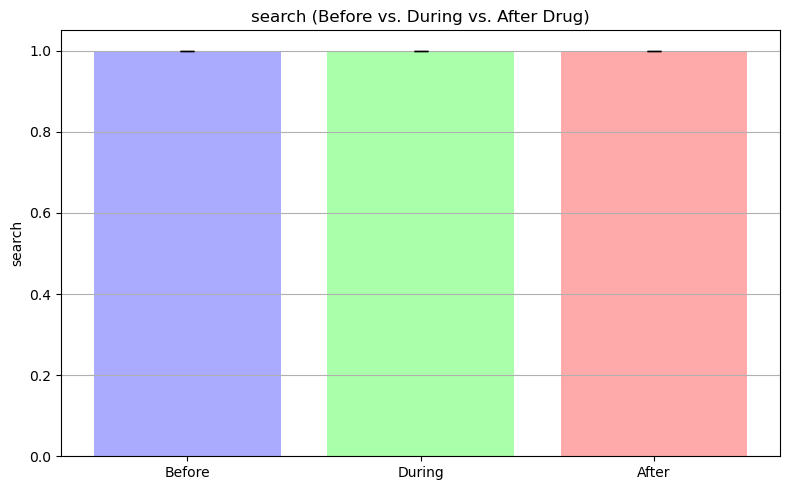

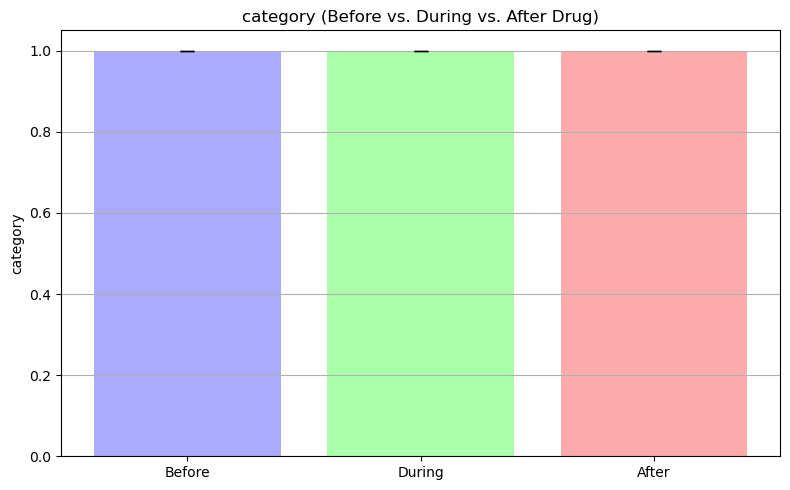

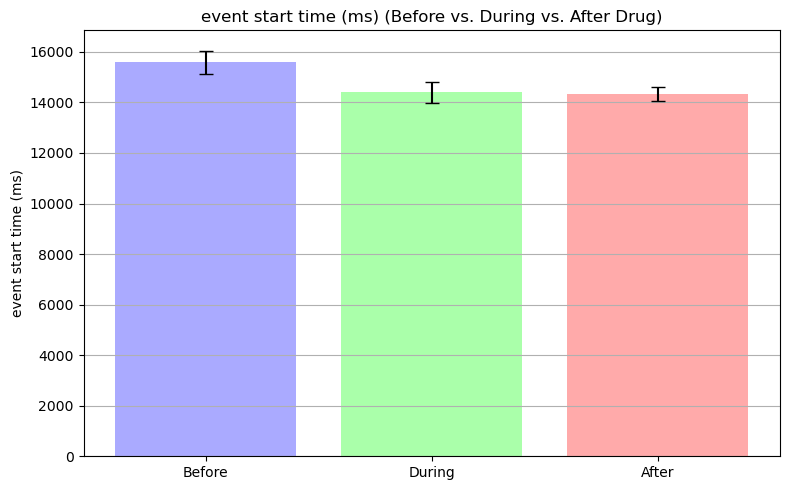

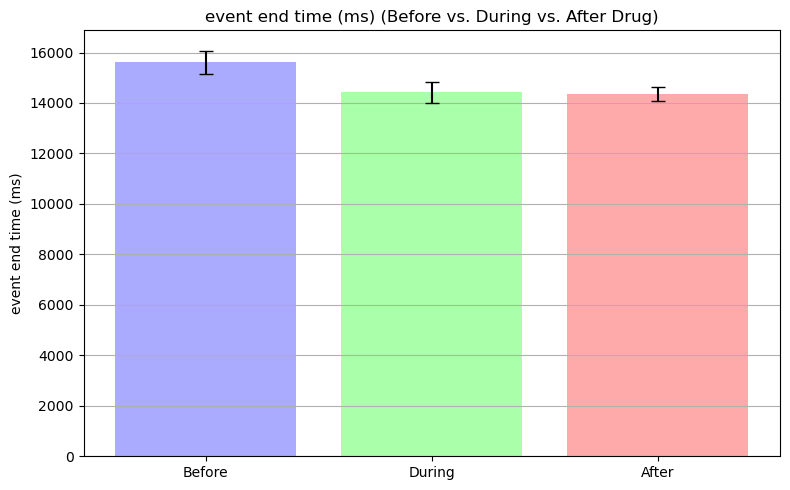

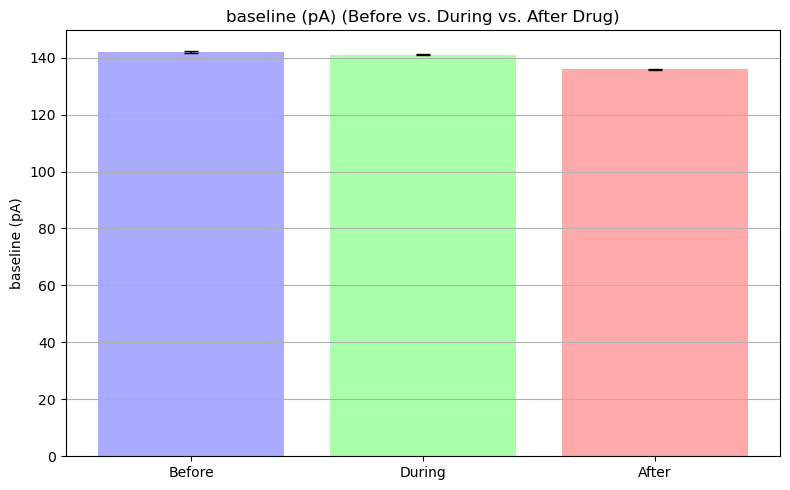

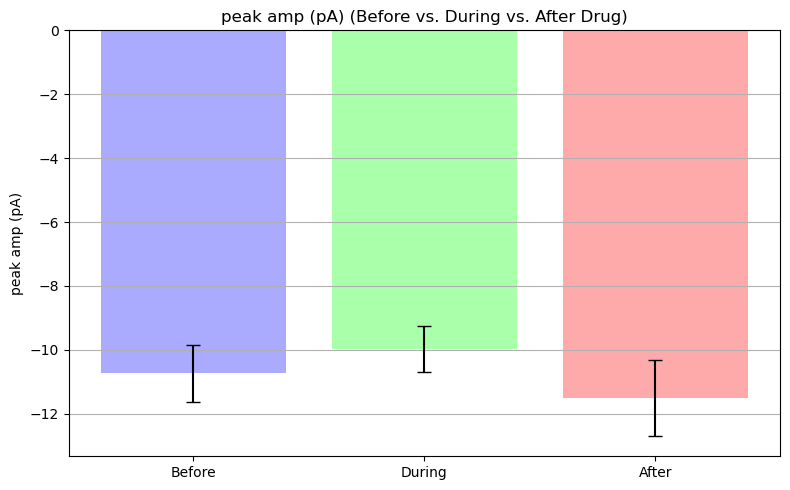

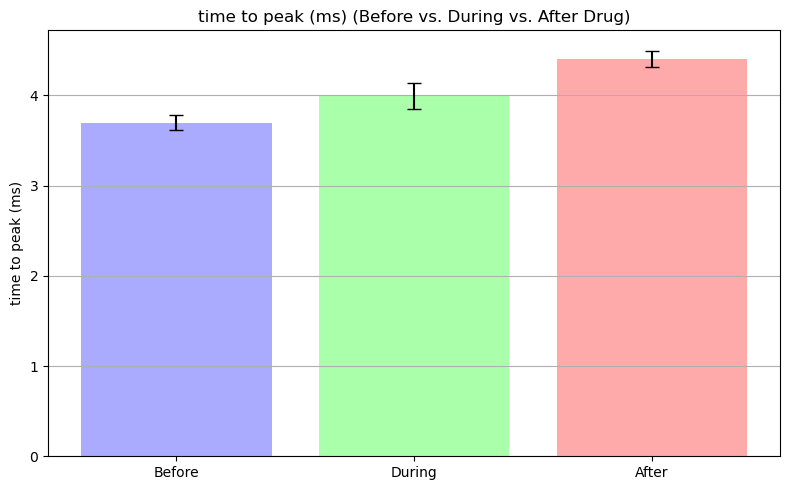

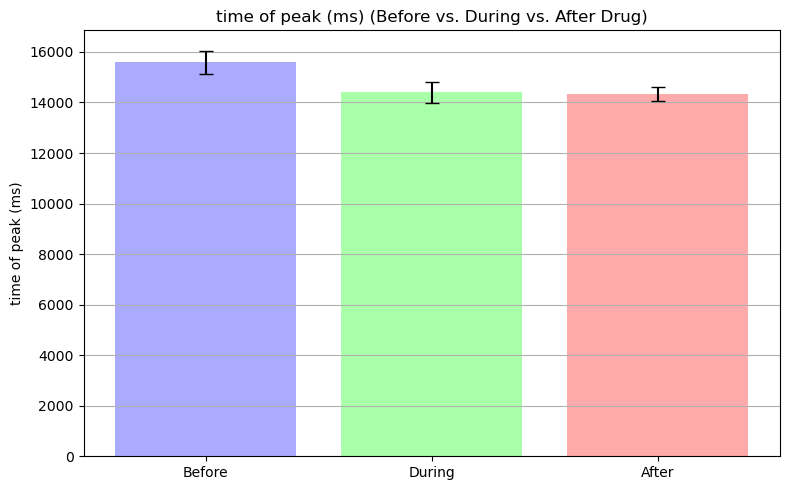

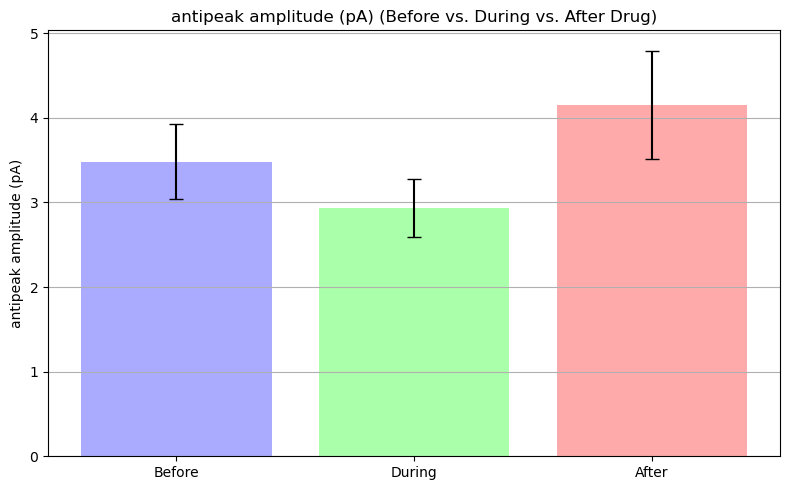

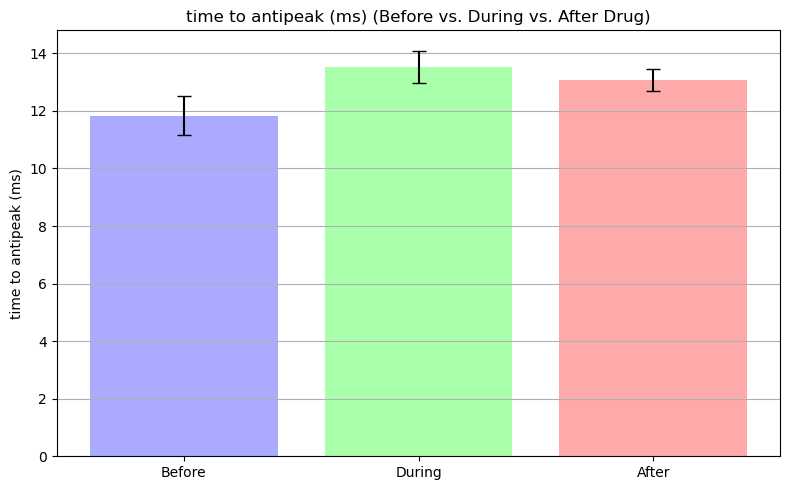

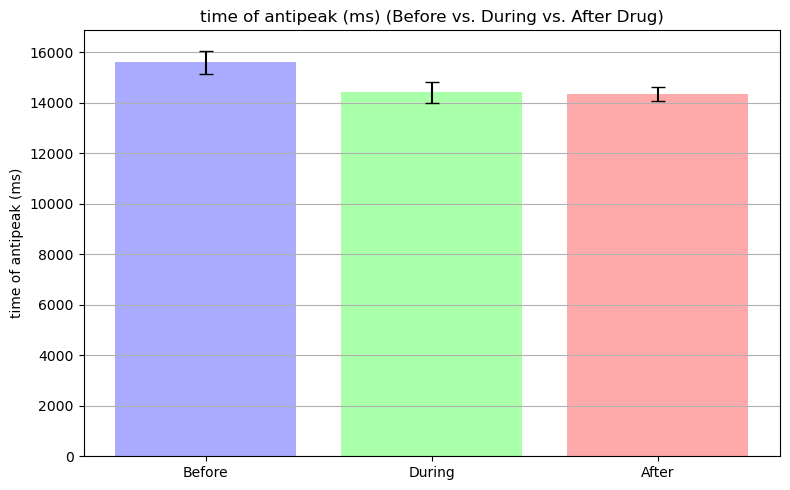

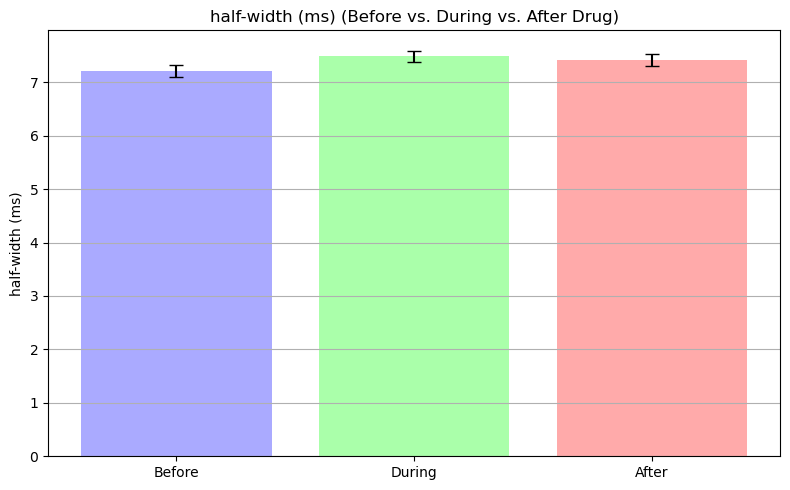

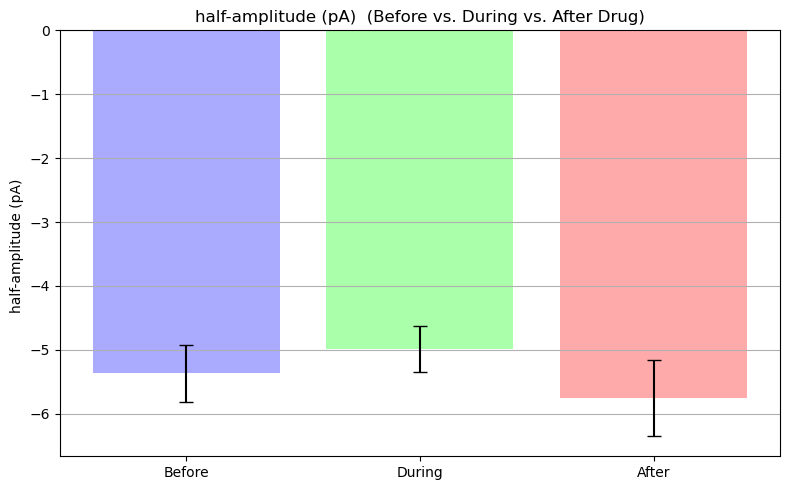

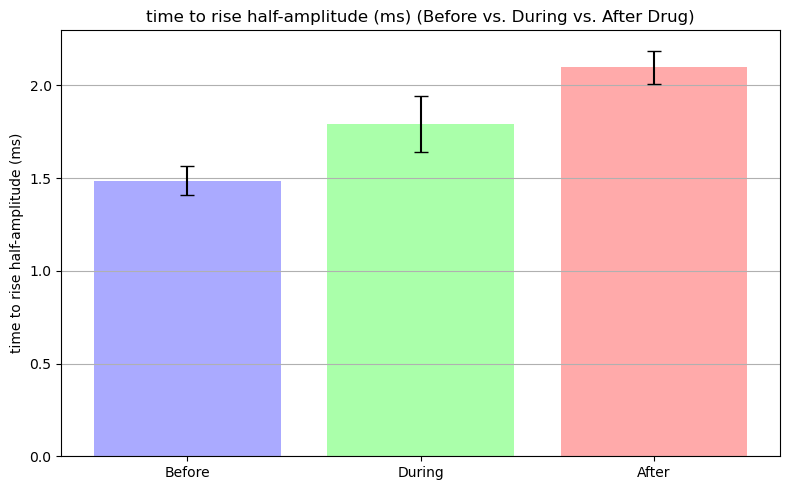

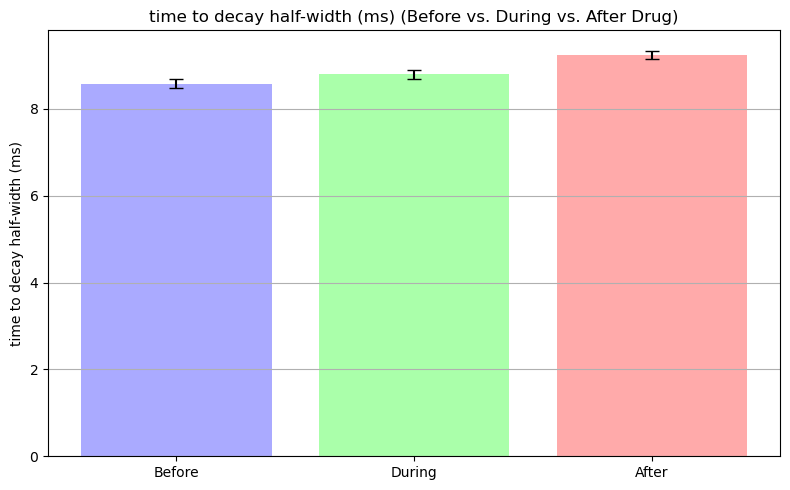

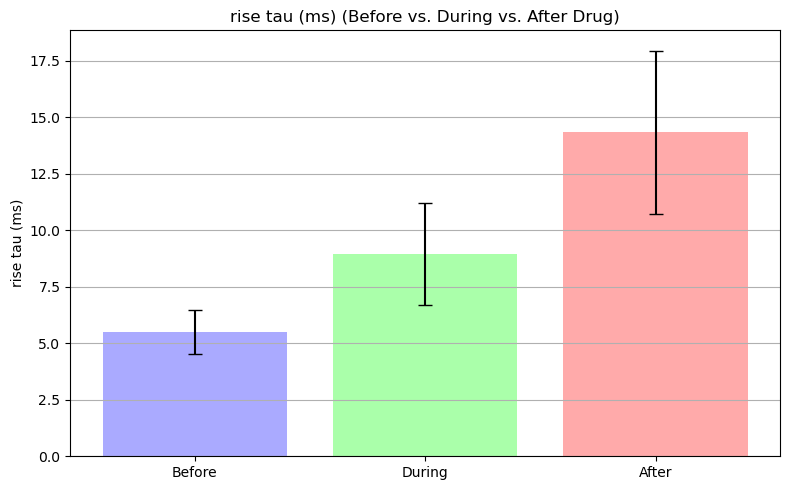

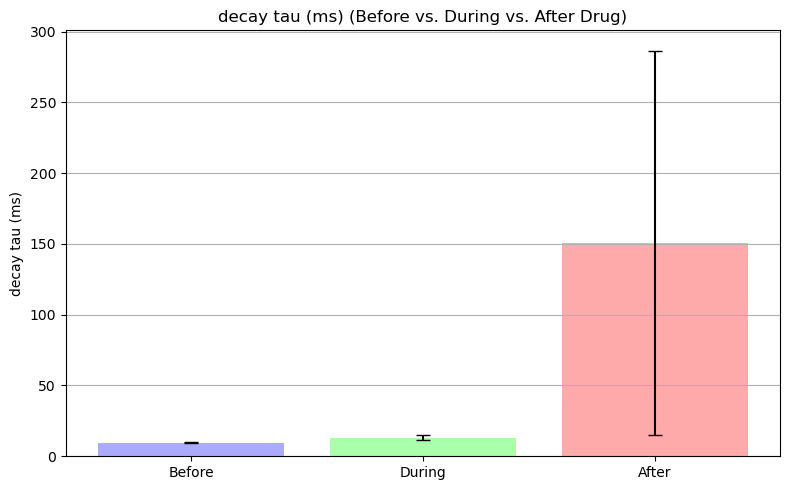

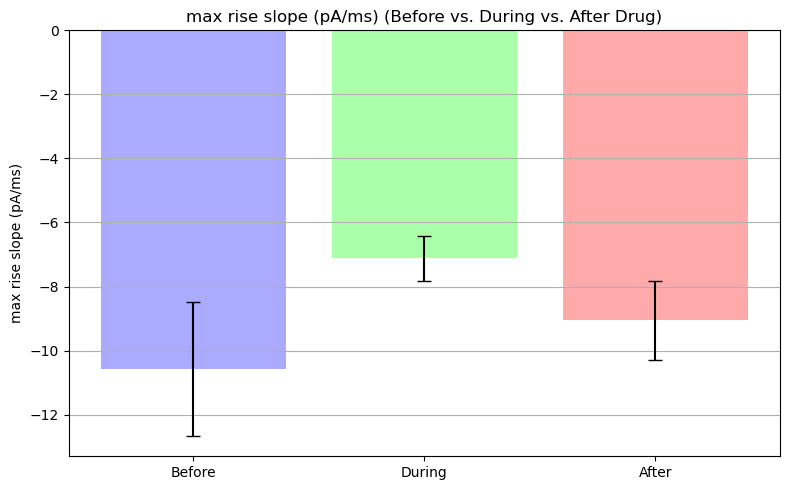

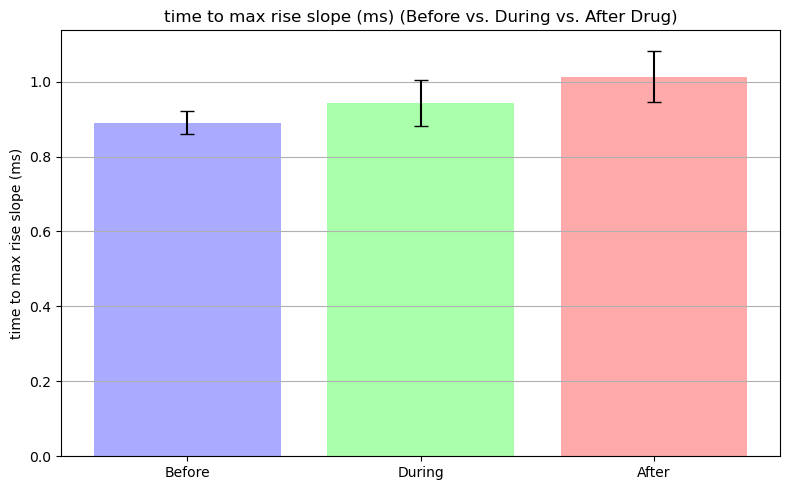

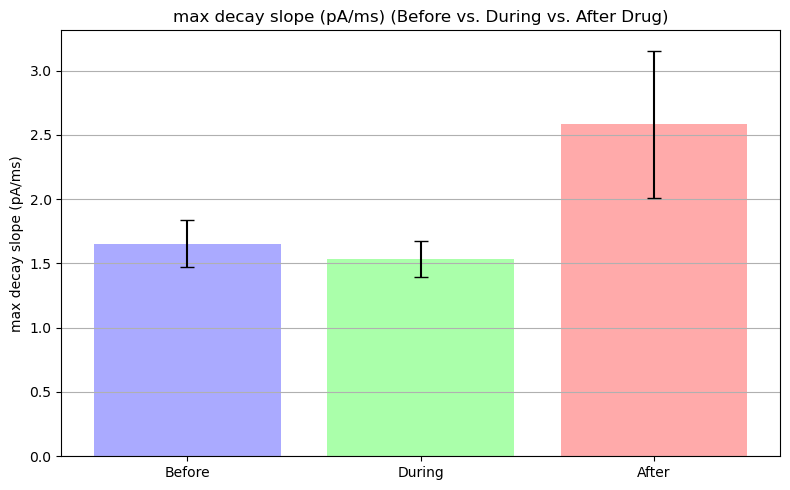

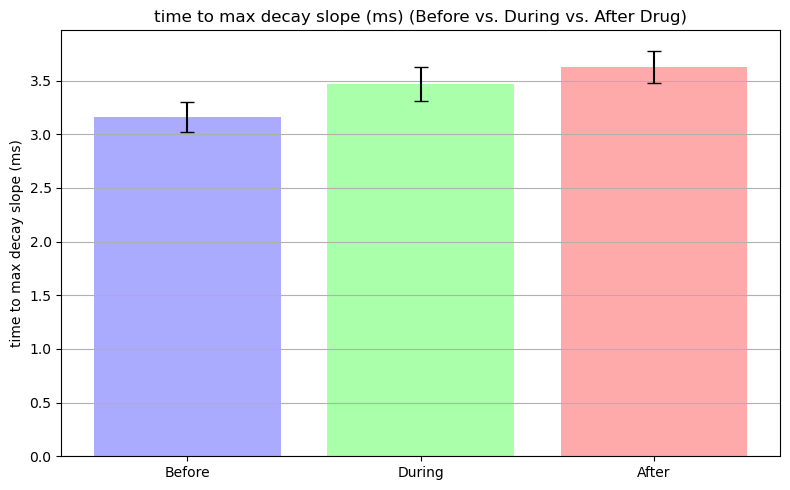

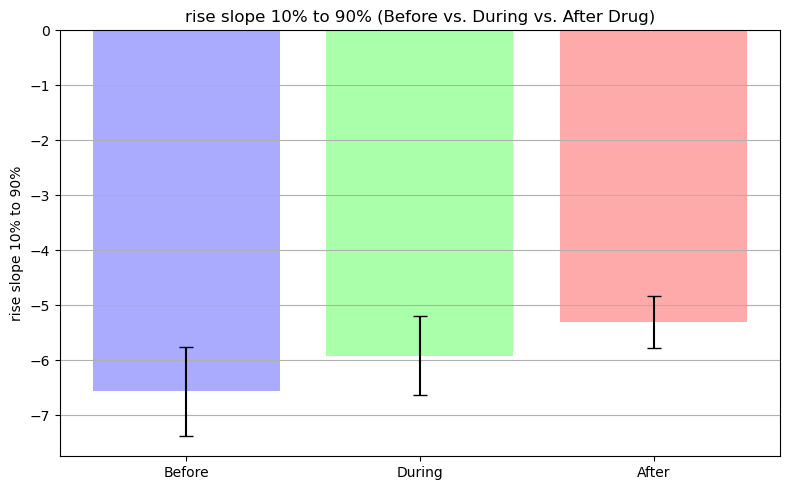

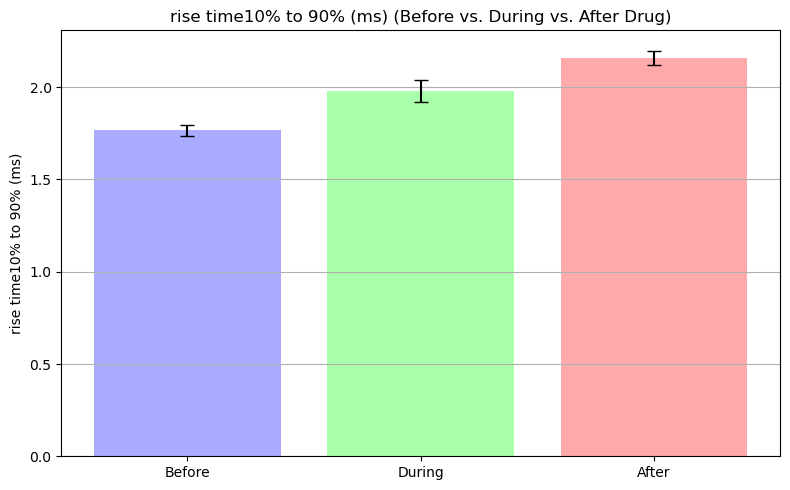

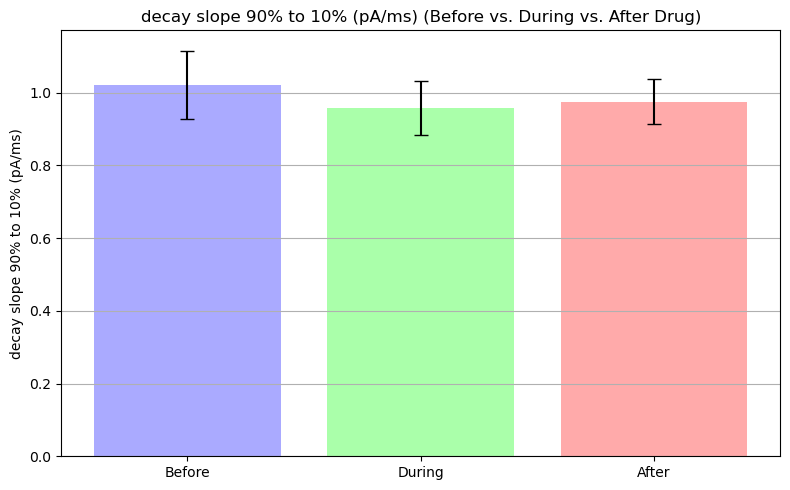

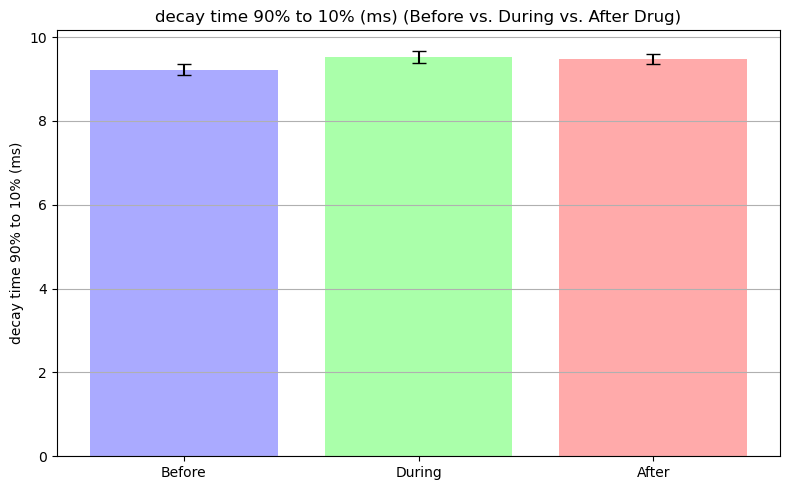

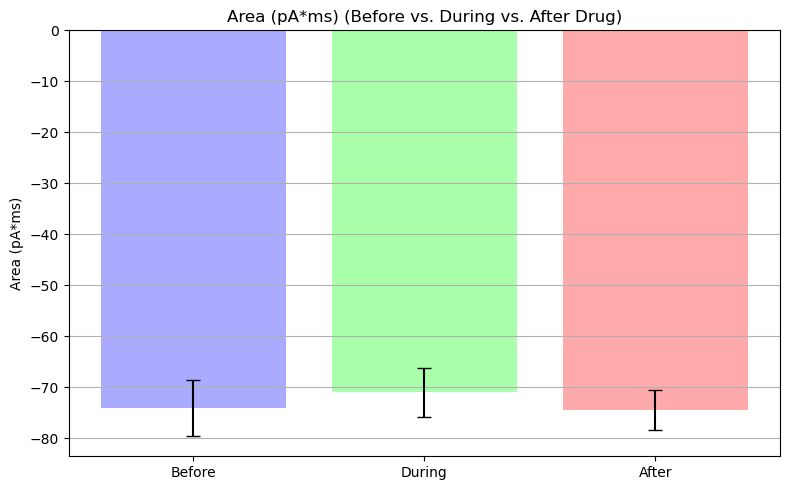

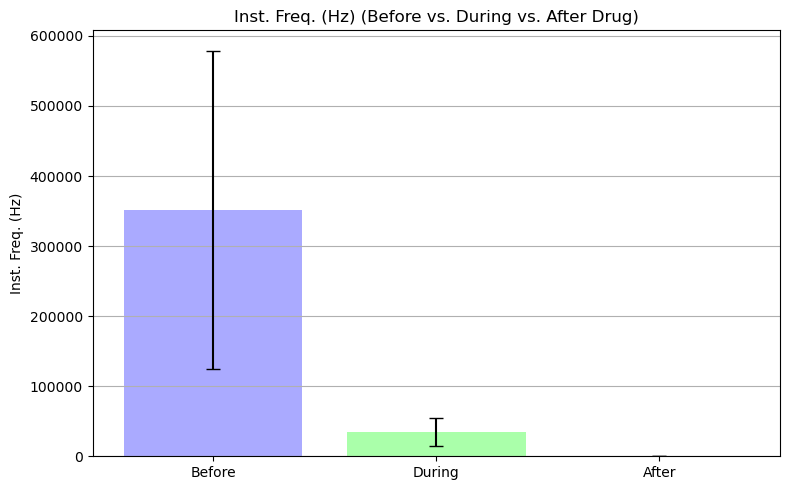

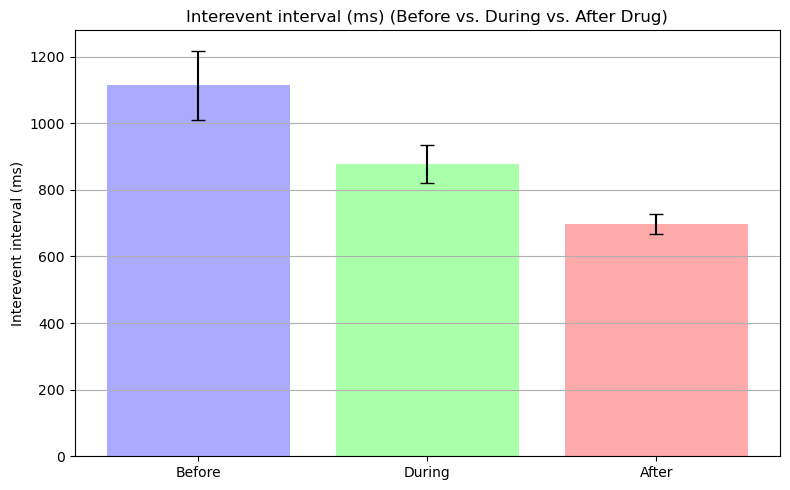

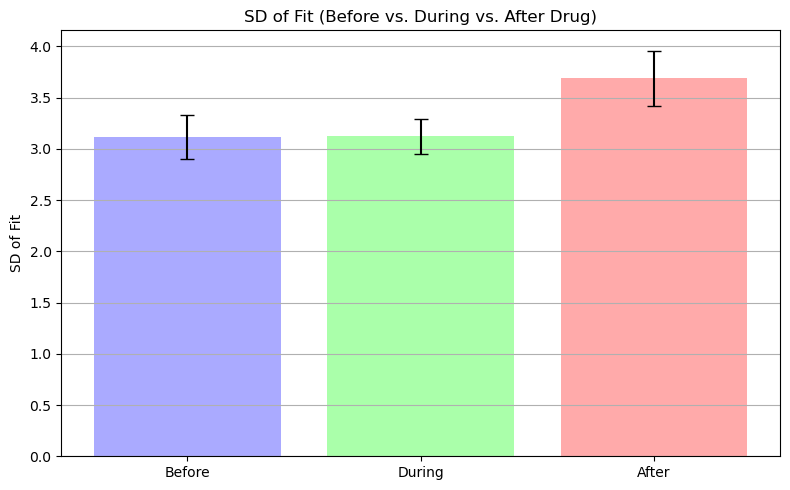

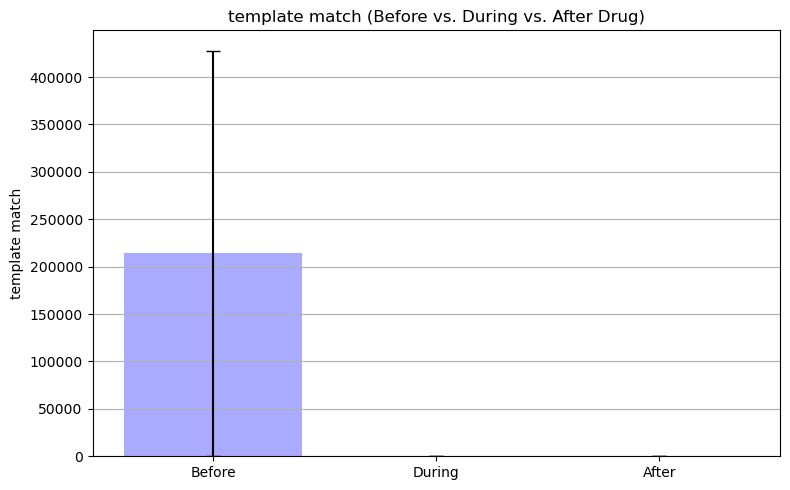

In [13]:
plot_drug_application_effects("/Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/25612002.csv", start_sweep=11, end_sweep=23)

In [14]:
def plot_drug_application_effects_with_points(csv_path, start_sweep, end_sweep, trace_column='trace'):
    # Load and convert
    df = pd.read_csv(csv_path)
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    numeric_df[trace_column] = df[trace_column]

    # Define periods
    def label_period(trace_num):
        if trace_num < start_sweep:
            return "Before"
        elif trace_num > end_sweep:
            return "After"
        elif start_sweep < trace_num < end_sweep:
            return "During"
        else:
            return None  # Exclude exact boundaries

    numeric_df['period'] = numeric_df[trace_column].apply(label_period)
    filtered_df = numeric_df[numeric_df['period'].notna()]

    # Columns to plot
    columns_to_plot = [col for col in filtered_df.columns if col not in [trace_column, 'period'] and filtered_df[col].dtype != 'O']

    for col in columns_to_plot:
        plt.figure(figsize=(8, 5))

        # Scatter plot of individual data points
        sns.stripplot(data=filtered_df, x='period', y=col, jitter=True, alpha=0.6)

        # Overlay mean ± SEM
        means = filtered_df.groupby('period')[col].mean()
        sems = filtered_df.groupby('period')[col].sem()
        plt.errorbar(x=means.index, y=means.values, yerr=sems.values, fmt='o', color='black', capsize=5, label='Mean ± SEM')

        plt.title(f'{col} by Drug Application Period')
        plt.ylabel(col)
        plt.xlabel('Condition')
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.legend()
        plt.show()

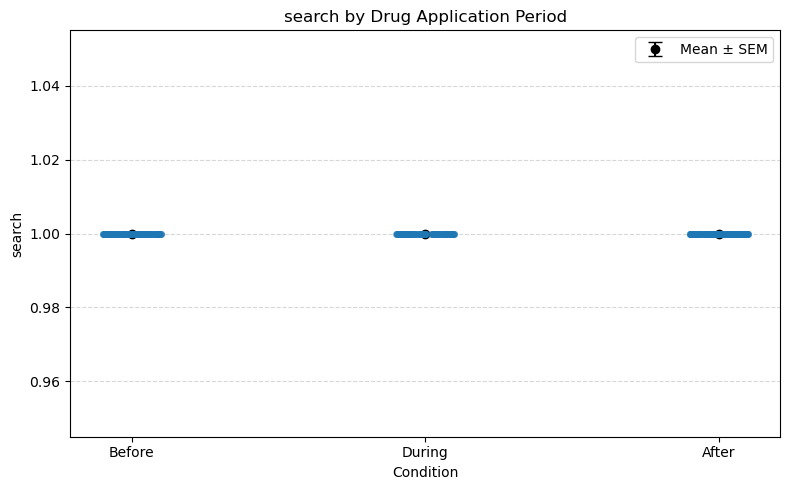

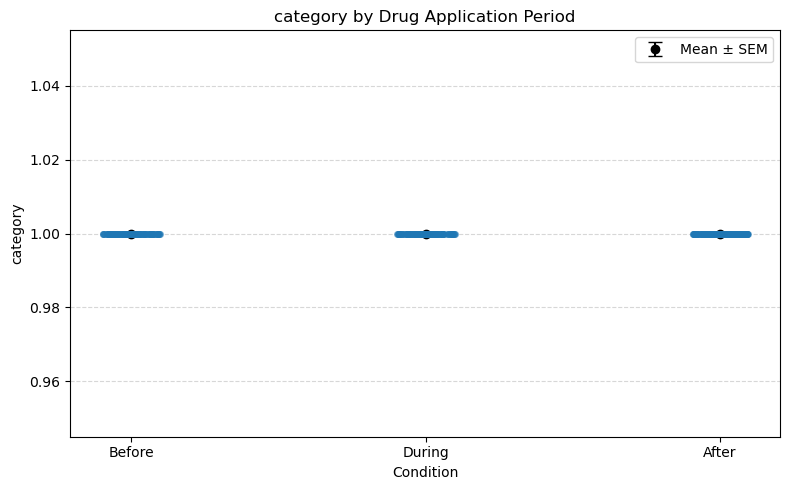

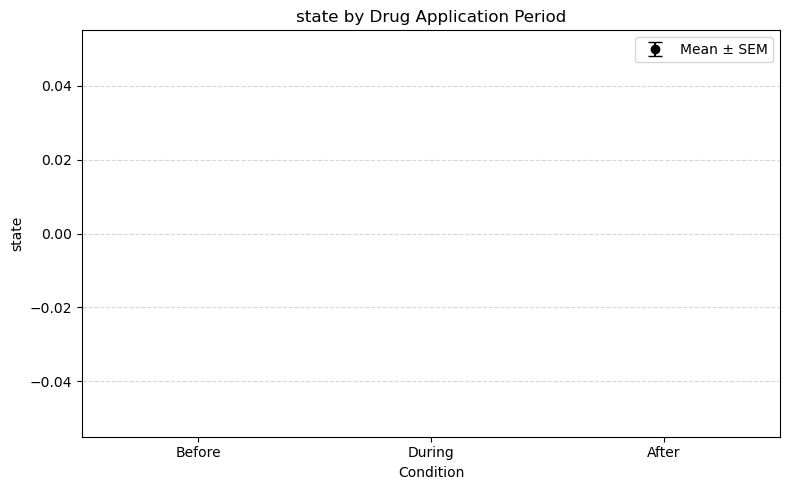

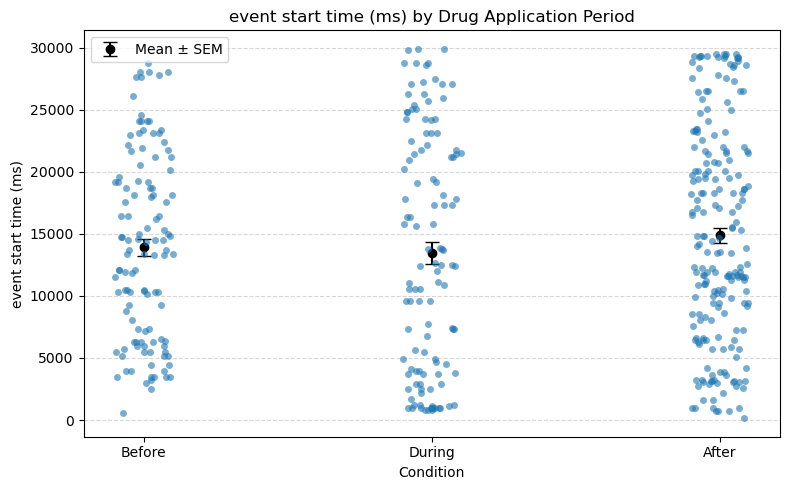

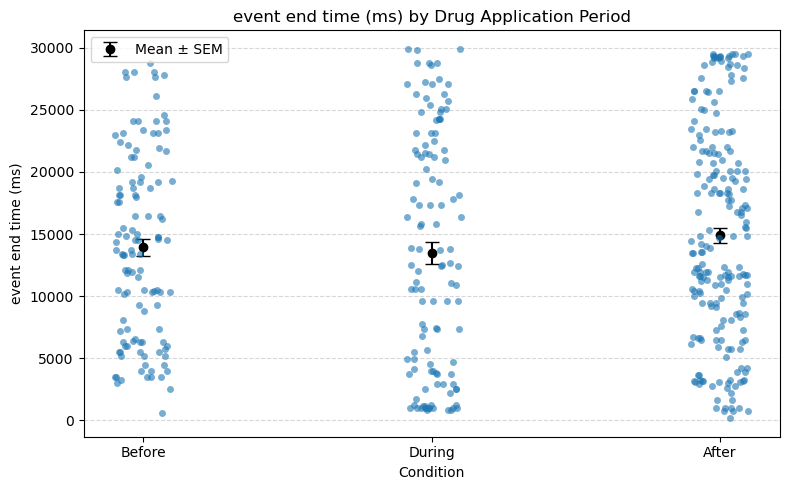

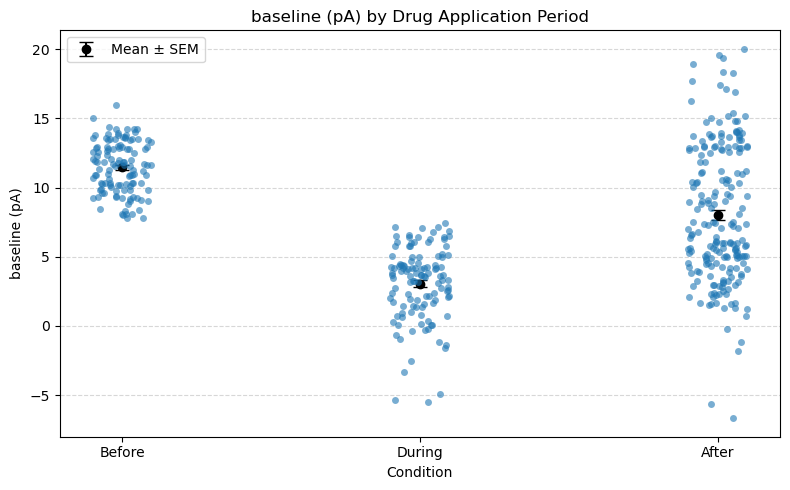

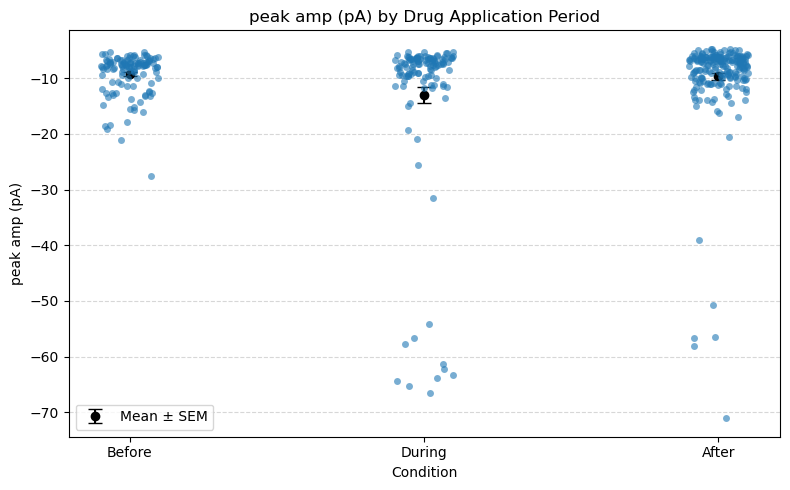

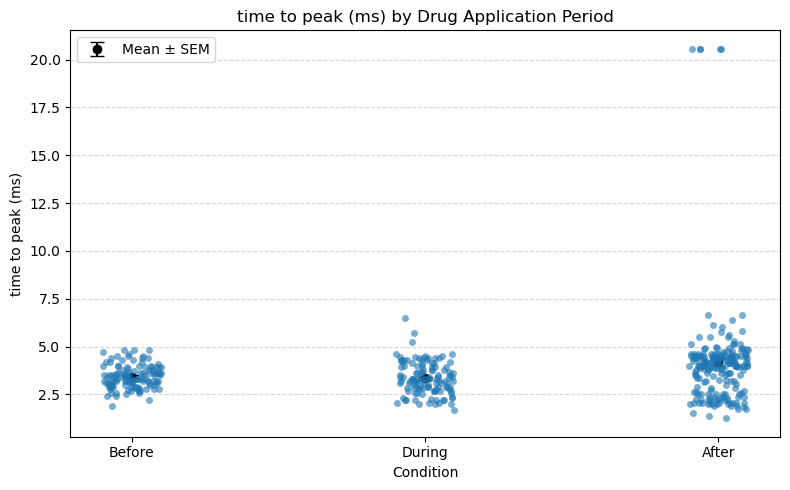

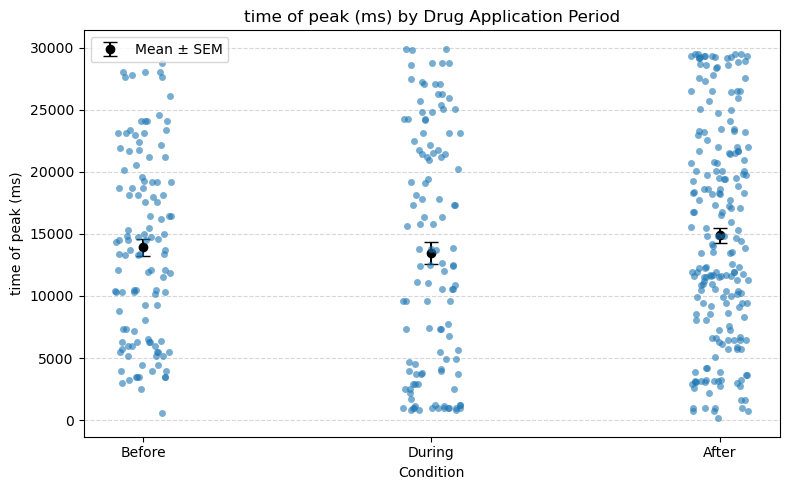

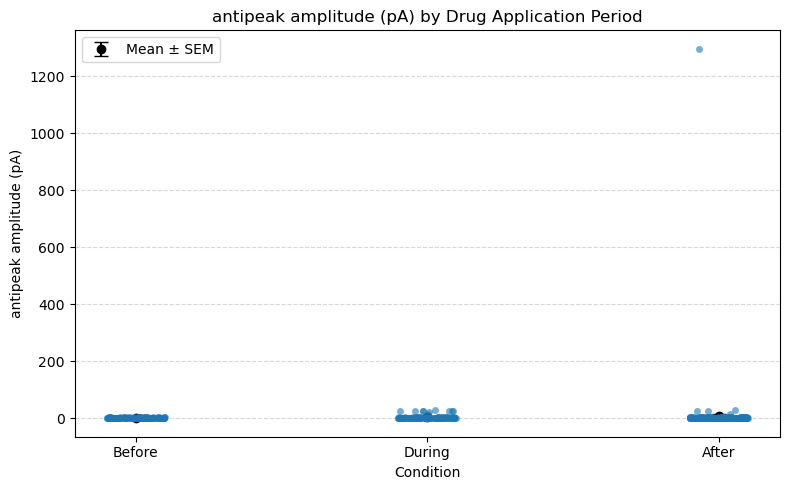

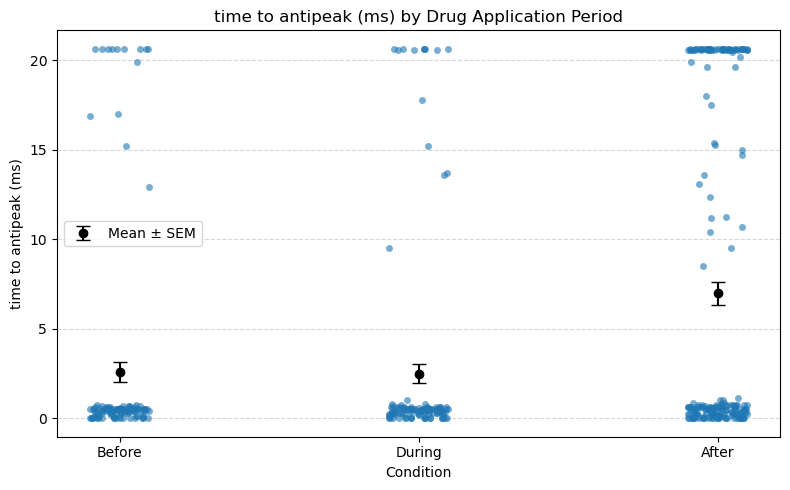

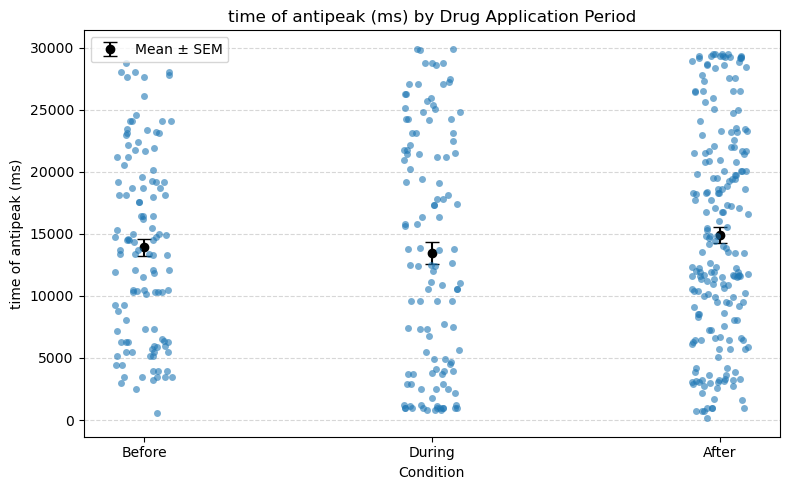

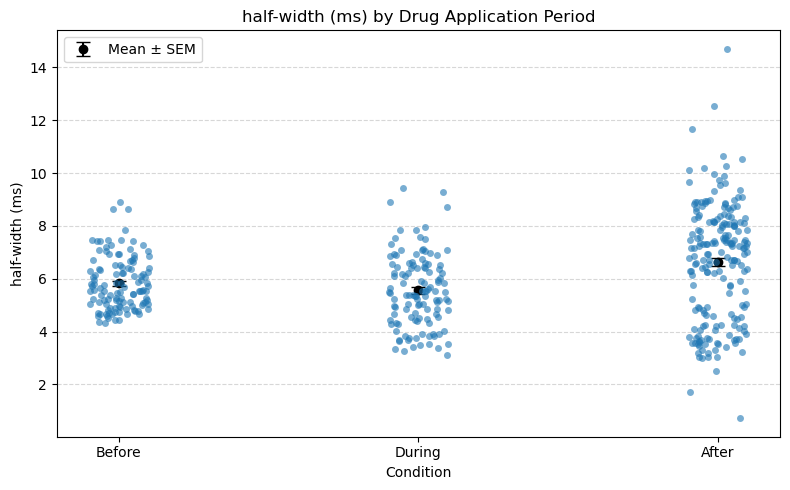

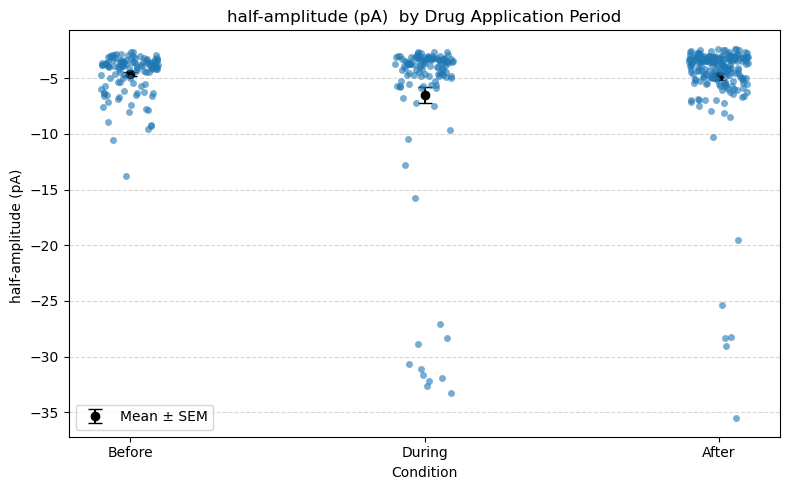

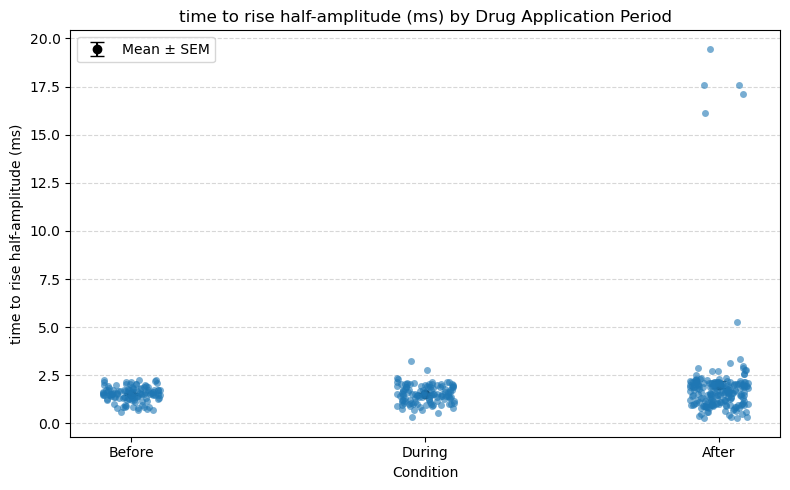

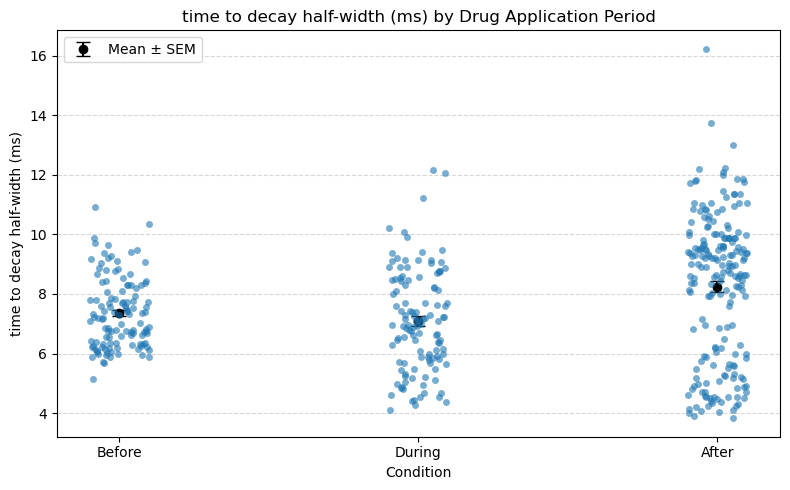

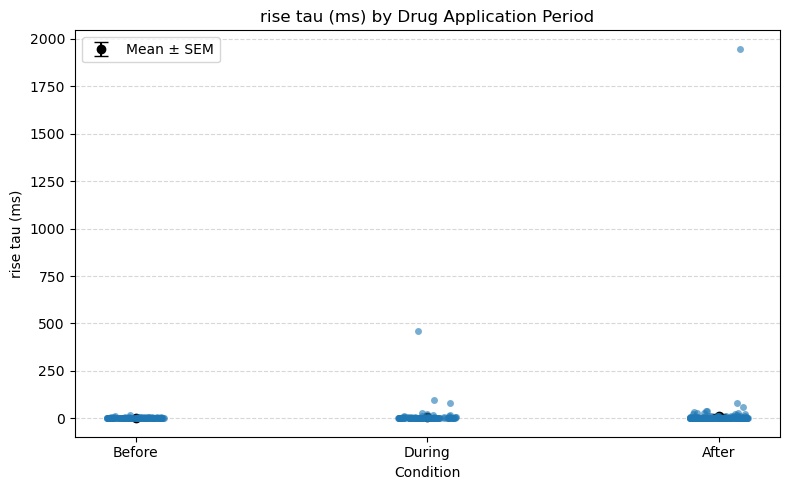

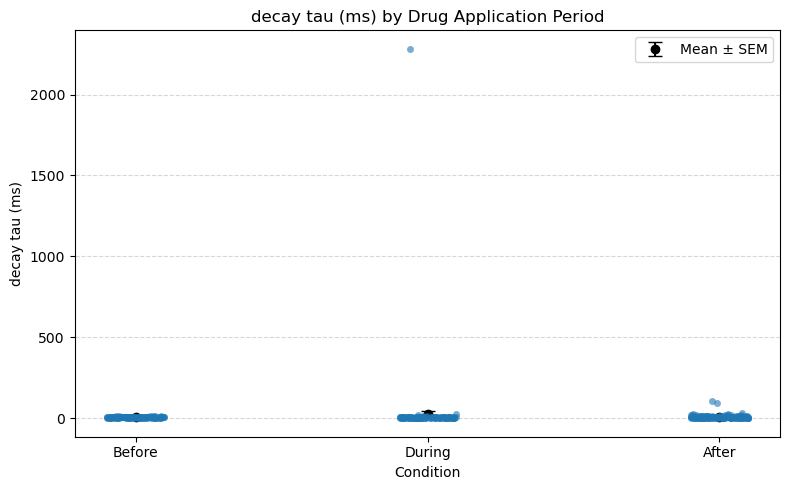

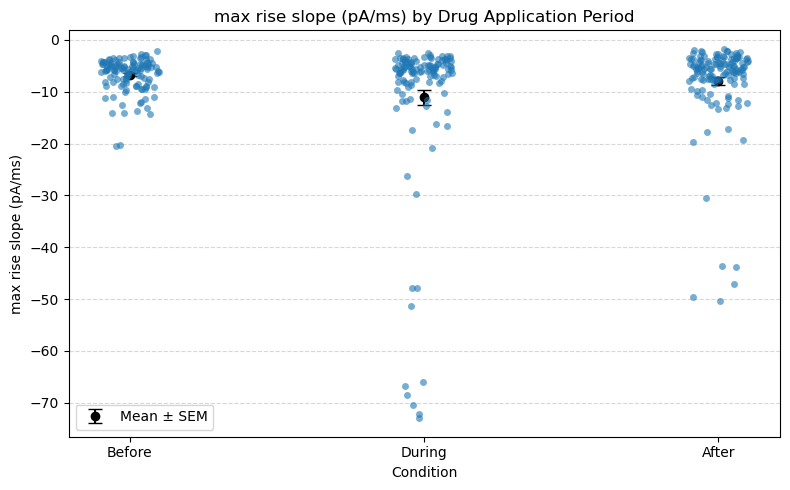

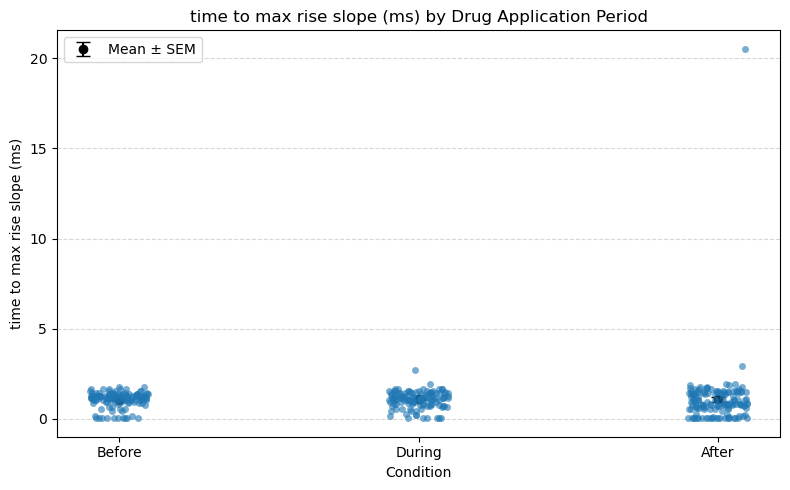

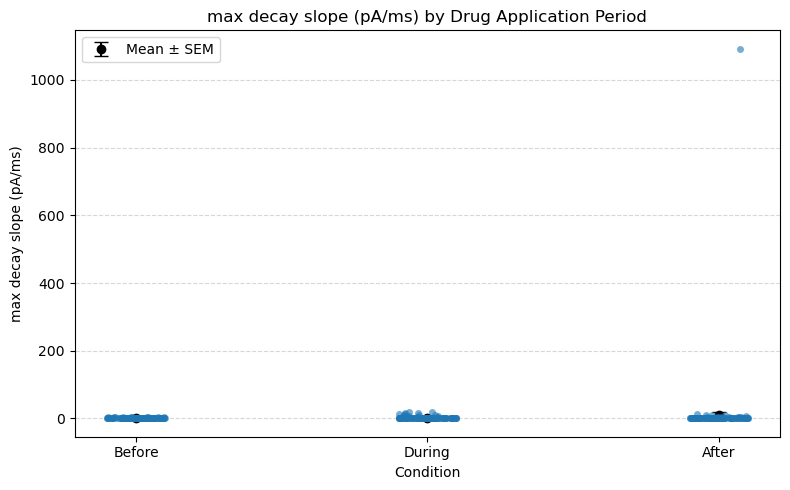

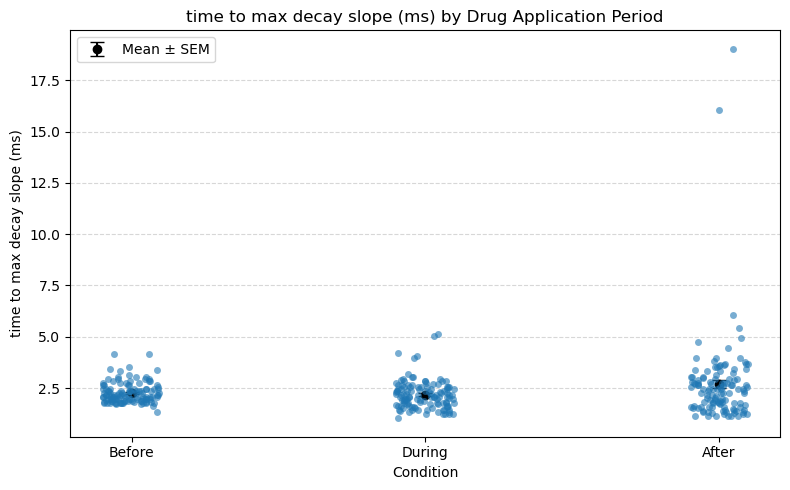

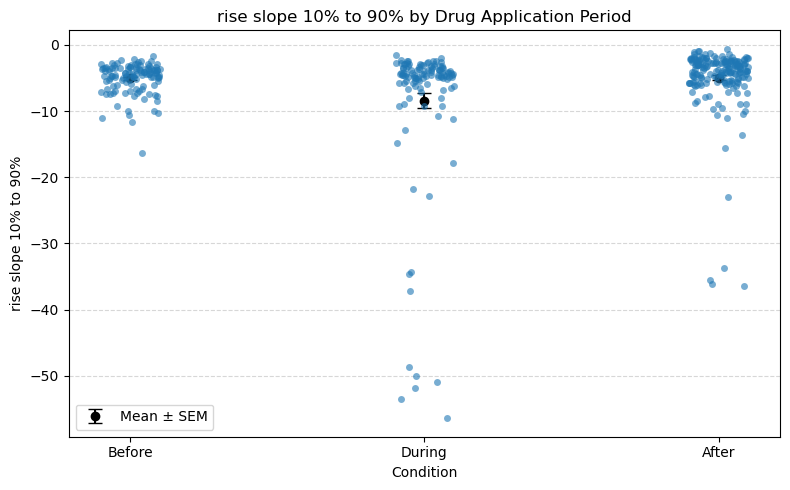

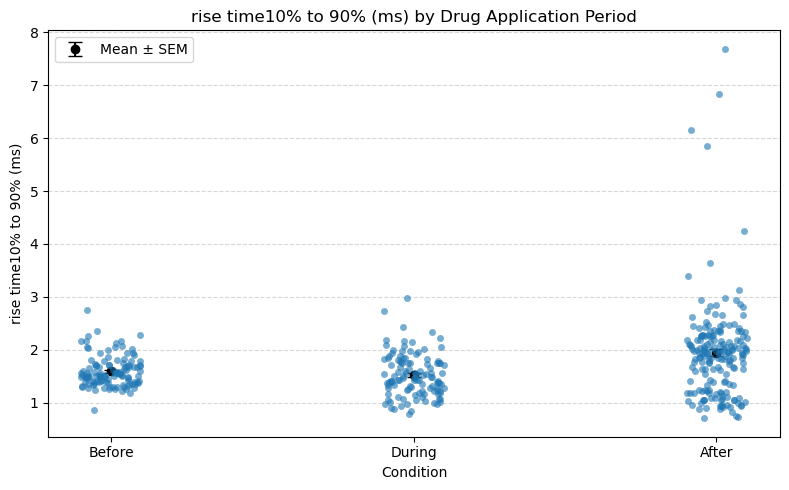

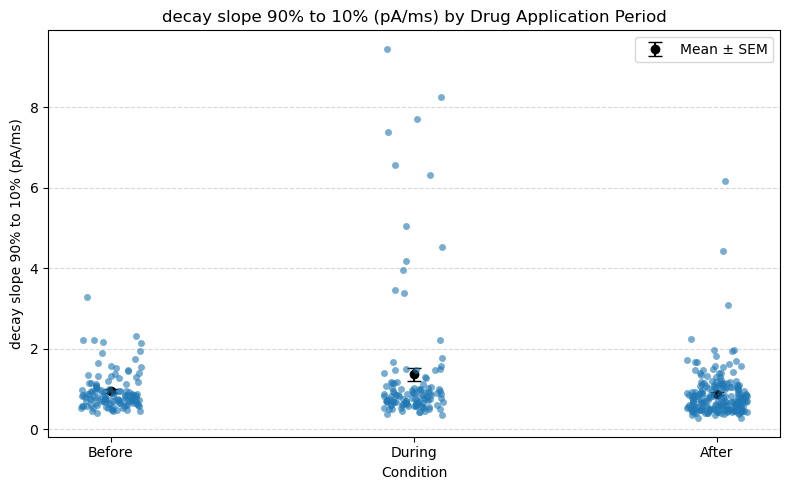

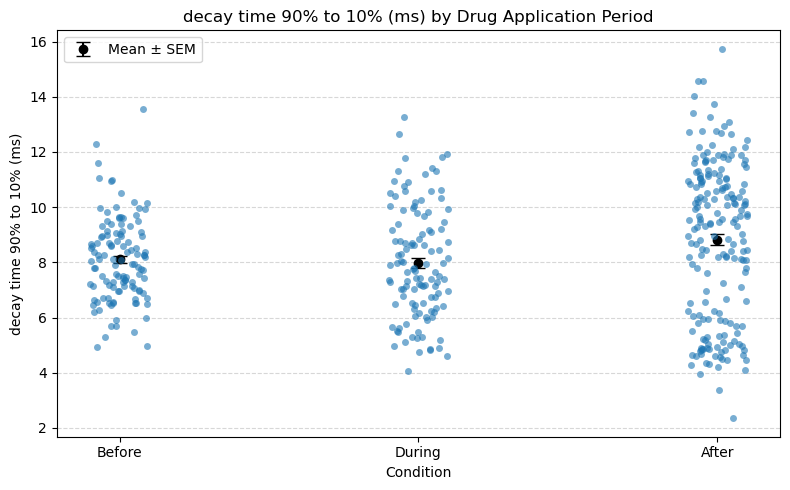

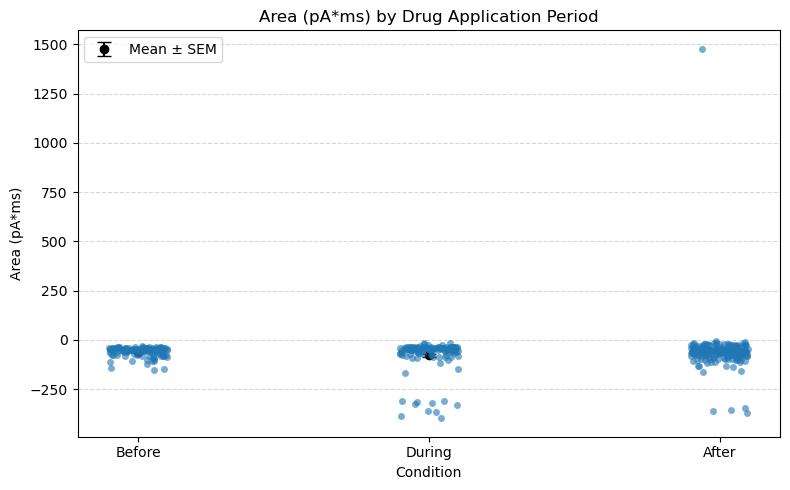

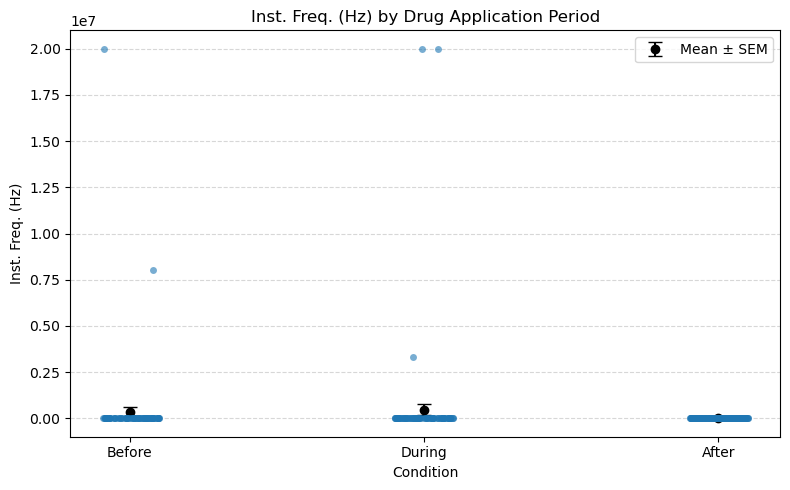

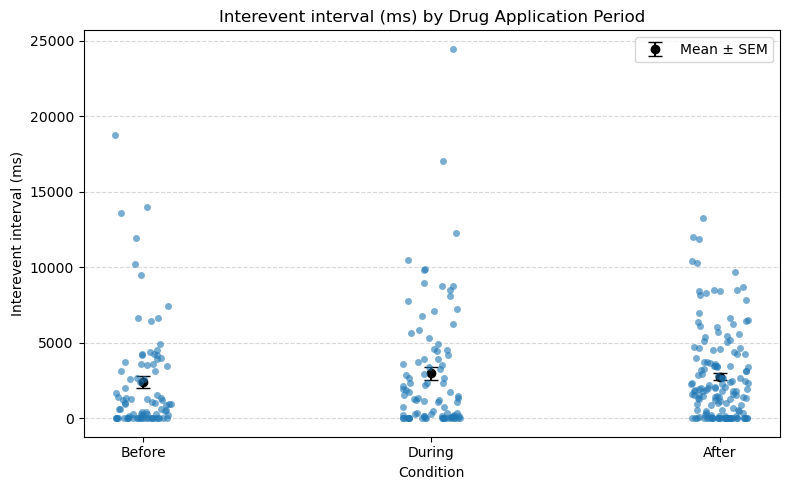

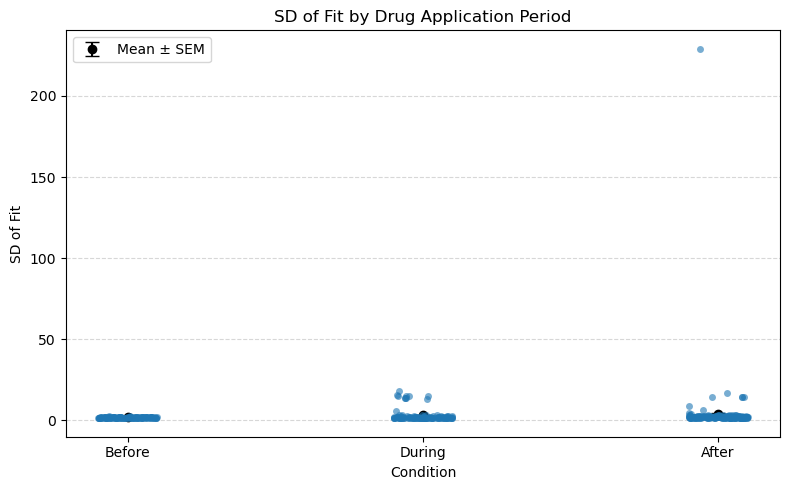

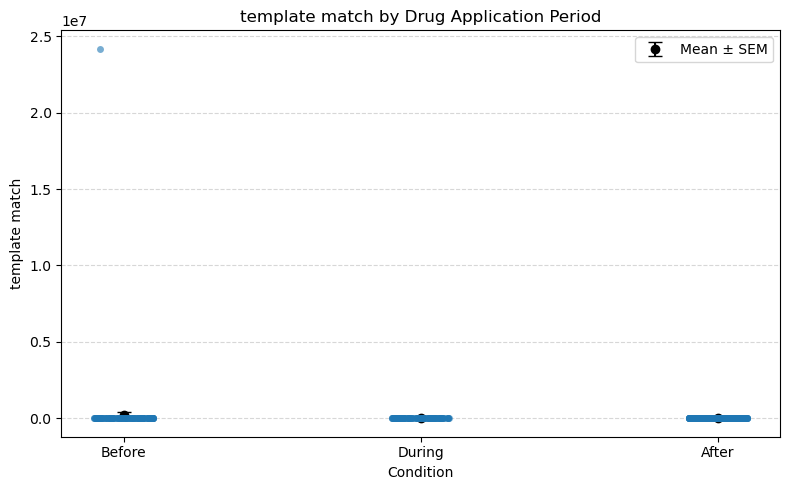

In [23]:
plot_drug_application_effects_with_points("/Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/25603010.csv", start_sweep=11, end_sweep=23)

In [16]:
def plot_and_save_all_csvs_in_directory(
    folder_path, start_sweep, end_sweep, trace_column='trace', output_folder=None
):
    if output_folder is None:
        output_folder = os.path.join(folder_path, "drug_analysis_plots")
    os.makedirs(output_folder, exist_ok=True)

    # List all CSV files
    csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')]

    for csv_file in csv_files:
        csv_path = os.path.join(folder_path, csv_file)
        print(f"Processing: {csv_file}")
        
        try:
            df = pd.read_csv(csv_path)
            numeric_df = df.apply(pd.to_numeric, errors='coerce')
            numeric_df[trace_column] = df[trace_column]

            def label_period(trace_num):
                if trace_num < start_sweep:
                    return "Before"
                elif trace_num > end_sweep:
                    return "After"
                elif start_sweep < trace_num < end_sweep:
                    return "During"
                else:
                    return None

            numeric_df['period'] = numeric_df[trace_column].apply(label_period)
            filtered_df = numeric_df[numeric_df['period'].notna()]
            columns_to_plot = [
                col for col in filtered_df.columns
                if col not in [trace_column, 'period'] and filtered_df[col].dtype != 'O'
            ]

            pdf_filename = os.path.splitext(csv_file)[0] + "_drug_analysis.pdf"
            pdf_path = os.path.join(output_folder, pdf_filename)
            
            with PdfPages(pdf_path) as pdf:
                for col in columns_to_plot:
                    plt.figure(figsize=(8, 5))
                    sns.stripplot(data=filtered_df, x='period', y=col, jitter=True, alpha=0.6)
                    
                    means = filtered_df.groupby('period')[col].mean()
                    sems = filtered_df.groupby('period')[col].sem()
                    plt.errorbar(x=means.index, y=means.values, yerr=sems.values, fmt='o', color='black', capsize=5, label='Mean ± SEM')
                    
                    plt.title(f'{col} by Drug Application Period')
                    plt.ylabel(col)
                    plt.xlabel('Condition')
                    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
                    plt.tight_layout()
                    plt.legend()
                    pdf.savefig()
                    plt.close()

            print(f"Saved: {pdf_path}")

        except Exception as e:
            print(f"Failed to process {csv_file}: {e}")

In [29]:
plot_and_save_all_csvs_in_directory(
    folder_path="/Users/jayashri/Desktop/sEPSCsGranuleCell_csvs",
    start_sweep=11,
    end_sweep=23
)

Processing: 25610011.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25610011_drug_analysis.pdf
Processing: 25612002.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25612002_drug_analysis.pdf
Processing: 25610006.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25610006_drug_analysis.pdf
Processing: 25603002.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25603002_drug_analysis.pdf
Processing: 25603006.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25603006_drug_analysis.pdf
Processing: 25603010.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25603010_drug_analysis.pdf
Processing: 25609016.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25609016_drug_analysis.pdf
Processing: 25609003.csv


/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_36619/1703988655.py:16: DtypeWarning: Columns (16,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25609003_drug_analysis.pdf
Processing: 25610019.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25610019_drug_analysis.pdf
Processing: 25612008.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25612008_drug_analysis.pdf
Processing: 25609011.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25609011_drug_analysis.pdf
Processing: 25609007.csv
Saved: /Users/jayashri/Desktop/sEPSCsGranuleCell_csvs/drug_analysis_plots/25609007_drug_analysis.pdf


In [18]:
def plot_and_save_all_csvs_in_directory(
    folder_path, start_sweep, end_sweep, trace_column='trace', output_folder=None
):
    if output_folder is None:
        output_folder = os.path.join(folder_path, "drug_analysis_plots")
    os.makedirs(output_folder, exist_ok=True)

    # List all CSV files
    csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')]

    for csv_file in csv_files:
        csv_path = os.path.join(folder_path, csv_file)
        print(f"Processing: {csv_file}")
        
        try:
            df = pd.read_csv(csv_path)
            numeric_df = df.apply(pd.to_numeric, errors='coerce')
            numeric_df[trace_column] = df[trace_column]

            def label_period(trace_num):
                if trace_num < start_sweep:
                    return "Before"
                elif trace_num > end_sweep:
                    return "After"
                elif start_sweep < trace_num < end_sweep:
                    return "During"
                else:
                    return None

            numeric_df['period'] = numeric_df[trace_column].apply(label_period)
            filtered_df = numeric_df[numeric_df['period'].notna()]
            columns_to_plot = [
                col for col in filtered_df.columns
                if col not in [trace_column, 'period'] and filtered_df[col].dtype != 'O'
            ]

            for col in columns_to_plot:
                plt.figure(figsize=(8, 5))
                sns.stripplot(data=filtered_df, x='period', y=col, jitter=True, alpha=0.6)
                
                means = filtered_df.groupby('period')[col].mean()
                sems = filtered_df.groupby('period')[col].sem()
                plt.errorbar(x=means.index, y=means.values, yerr=sems.values, fmt='o', color='black', capsize=5, label='Mean ± SEM')
                
                plt.title(f'{col} by Drug Application Period')
                plt.ylabel(col)
                plt.xlabel('Condition')
                plt.grid(True, axis='y', linestyle='--', alpha=0.5)
                plt.tight_layout()
                plt.legend()

                # Save as PNG
                base_filename = os.path.splitext(csv_file)[0]
                png_filename = f"{base_filename}_{col}_drug_analysis.png"
                png_path = os.path.join(output_folder, png_filename)
                plt.savefig(png_path, dpi=300)
                plt.close()

            print(f"Saved plots for: {csv_file}")

        except Exception as e:
            print(f"Failed to process {csv_file}: {e}")

Processing: 25521006.csv
Failed to process 25521006.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25521006_max rise slope (pA/ms)_drug_analysis.png'
Processing: 25521012.csv
Failed to process 25521012.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25521012_max rise slope (pA/ms)_drug_analysis.png'
Processing: 25521002.csv
Failed to process 25521002.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25521002_max rise slope (pA/ms)_drug_analysis.png'
Processing: 25522003.csv
Failed to process 25522003.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25522003_max rise slope (pA/ms)_drug_analysis.png'


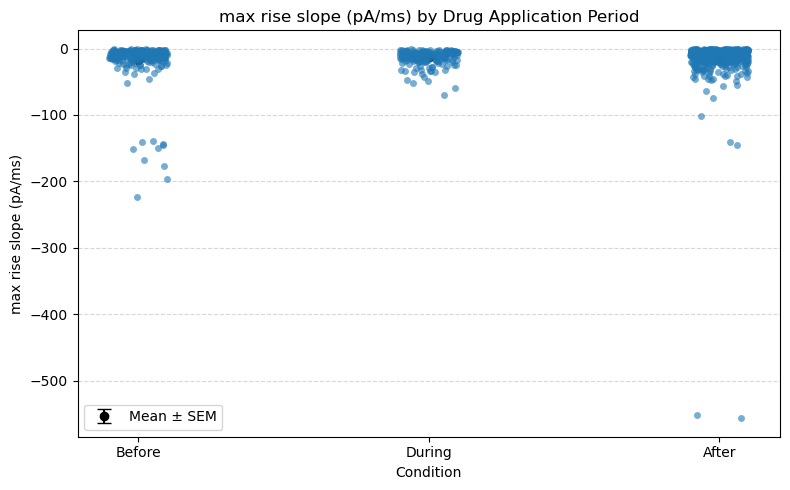

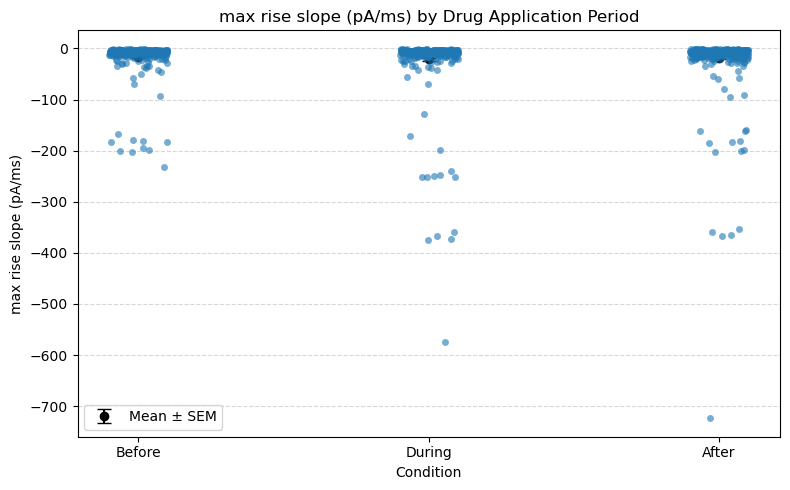

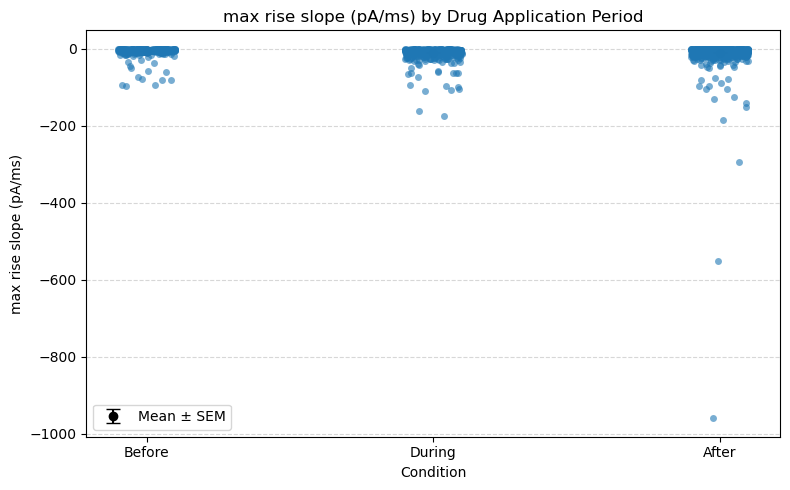

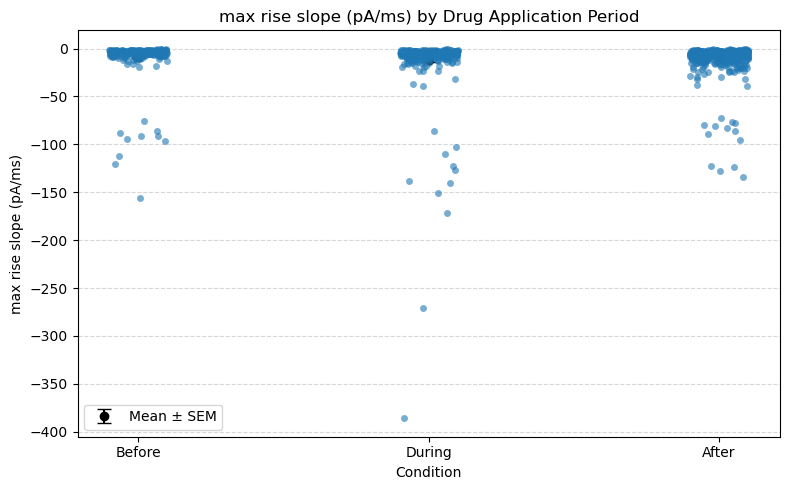

In [24]:
plot_and_save_all_csvs_in_directory(
    folder_path="/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM",
    start_sweep=11,
    end_sweep=23
)